### **Problem 1: Business Understanding**

In this digital era, monetary transactions are accelerating rapidly towards a cashless system along with which the risk of fraudulent transactions is also increasing.

Credit card fraud is the most common type of identity theft causing nightmare and distress to victims (customers) and businesses who have to compensate for the loss in addition to reputational loss for repeat offences.

Timely intervention on fraud alerts and customer reach is imperative for smooth running of business and retaining customer trust and loyalty to the financial institutions.

The model can serve as a real-world application of imbalanced classification and cost sensitive Machine Learning approaches.

In this exercice , we would build various Predictive machine learning models that can learn from preceding data and estimate the probability of a fraudulent credit card transaction.

The real world implementaiton entails monitoring the activities of
populations of users in order to estimate, perceive or avoid
objectionable behaviour, which consist of fraud, intrusion, and
defaulting.

**Problem Statement**

**The fundamental question we would try to address is** - In all of the classification machine learning algorithms available to us, which one should a credit card ussing company prioritize for detecting fradulent transactions without compromising customer trust and upholding its seamless reputation as a safe merchant.


**Real world demonstration of Fraud identification in banking and financial institution.**

### **Problem 2: Data Understanding**

Verified data source from the openml org-
https://api.openml.org/data/download/22121069/dataset
Datasets would be the historical transactions carried out against customers’ accounts . The target variable would be “class” , a binary variable representing fraud or otherwise.

The dataset (from OpenML) contains anonymized features (V1–V28) obtained via PCA transformation, along with

**time** - The time column represents the number of seconds elapsed since the very first transaction in the dataset. To convert this into a more readable 'time of day' format,we will generate a new column by assuming a reference start date (e.g., January 1, 2013, given this was 2013 EU Dataset ) at midnight and adding the elapsed seconds to it. This will allow us to see the transactions mapped to a 24-hour cycle.

**Amount - transaction amount**

**Class** - target variable identifying fraud (1) vs non-fraud transactions(otherwise- 0)

In a real-world scenario, additional features such as transaction location, device type, and login patterns would be useful but are not available due to privacy constraints. They are anonymized through PCA transformations to protect PII .

Even if Data exploration and interpretability and EDA would be limited in scope , the primary operating algorithms, evaluation metrics and predictive analysis does not change. Additionally , we would do multiple plots to understand relationsips between the features.

[Note]- The dataset is in arff format , hence we would use the scipy.io.arff library to read the file and convert into standard csv for ease.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.io import arff

# Import SMOTE library , the standard sklearn pipeline cannot be used here
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from datetime import datetime
from timeit import default_timer as timer

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder,MinMaxScaler
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV,StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, OneClassSVM

from sklearn.ensemble import RandomForestClassifier, IsolationForest, VotingClassifier

from sklearn.metrics import (accuracy_score, recall_score,f1_score,RocCurveDisplay,roc_auc_score, \
PrecisionRecallDisplay, precision_score, precision_recall_curve, classification_report, ConfusionMatrixDisplay, confusion_matrix)

In [3]:
# Connect to google drive to load the full campaign file
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/UCbDatasets/creditCardFraudDatasetFull_processed.csv")
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,class_bool
271653,164678.0,1.441431,-1.938175,-2.218584,-0.572909,0.302646,1.534190,-0.264413,0.266430,-0.378501,...,0.528181,-0.339425,-2.391025,-0.014940,0.110317,-0.007081,-0.032904,336.50,False,NaN
111526,72256.0,0.964633,-1.235181,-0.053873,-0.338503,-1.290163,-0.823817,-0.173382,-0.117579,-0.840852,...,-0.778958,-0.146312,0.559330,0.246841,1.045957,-0.120776,0.020819,204.90,False,NaN
222924,143180.0,2.034546,-0.312700,-3.128865,-0.640646,2.734745,3.119818,-0.074779,0.647926,0.436553,...,0.102776,0.058939,0.728937,0.392805,-0.201451,-0.019888,-0.070511,19.98,False,NaN
126266,77971.0,-0.637201,0.870700,-0.159059,-1.246669,2.405969,3.349278,0.133117,0.941500,-0.329657,...,-0.926874,-0.018419,0.979476,0.023081,0.091682,0.375029,0.181235,15.98,False,NaN
254154,156604.0,-1.511704,1.539798,-0.219245,-1.169864,0.722364,-1.451428,1.203552,0.148598,-0.825004,...,0.421310,-0.703373,0.115139,1.253551,0.365049,0.062191,0.013233,0.77,False,NaN


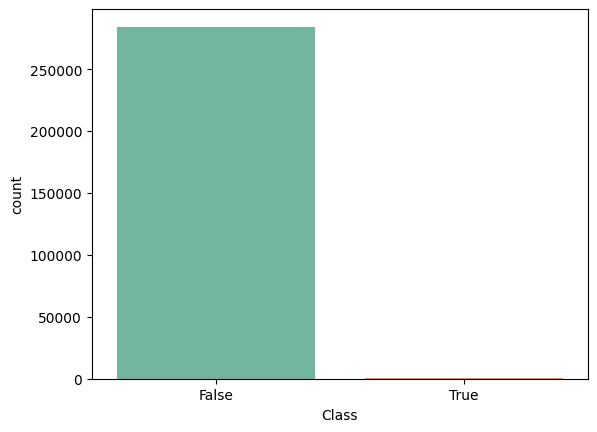

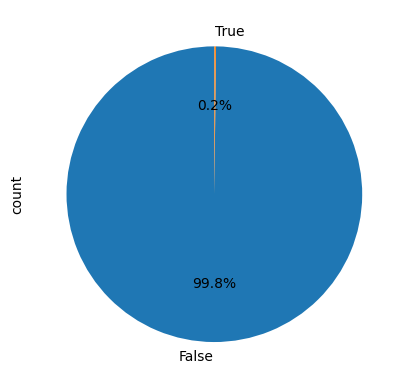

In [5]:
import warnings
warnings.filterwarnings("ignore")
df['Class'].value_counts()
#plot the countplot as normalized
sns.countplot(x='Class', data=df, palette='Set2')
plt.show()

#  draw pie chart
df['Class'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.show()

In [6]:
# map class variable values otherwise to 0 and fraud to 1
df['class_bool'] = df['Class'].map({False: 0, True: 1})
print(df["class_bool"].value_counts())
df.tail(2)

class_bool
0    284315
1       492
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,class_bool
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.0,False,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.0,False,0


### **3. Exploratory Data Analysis**

Inside this dataset, there are 31 columns out of which 28 are
named as v1-v28 to protect sensitive data.

The other columns represent Time, Amount and Class. Time
shows the time gap between the first transaction and the
following one. Amount is the amount of money transacted.

Class 0 represents a valid transaction and 1 represents a
fraudulent one.

We would plot different graphs to check for inconsistencies in the
dataset and to visually comprehend it:

**Data Cleaning**

In [7]:
# Remove duplicates
df.isnull().sum()# no null  - all 0s
df = df[~df.duplicated()]
df.shape

(283726, 32)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 32 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Time        283726 non-null  float64
 1   V1          283726 non-null  float64
 2   V2          283726 non-null  float64
 3   V3          283726 non-null  float64
 4   V4          283726 non-null  float64
 5   V5          283726 non-null  float64
 6   V6          283726 non-null  float64
 7   V7          283726 non-null  float64
 8   V8          283726 non-null  float64
 9   V9          283726 non-null  float64
 10  V10         283726 non-null  float64
 11  V11         283726 non-null  float64
 12  V12         283726 non-null  float64
 13  V13         283726 non-null  float64
 14  V14         283726 non-null  float64
 15  V15         283726 non-null  float64
 16  V16         283726 non-null  float64
 17  V17         283726 non-null  float64
 18  V18         283726 non-null  float64
 19  V19    

In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,class_bool
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [10]:
df['class_bool'].unique()

array([0, 1])

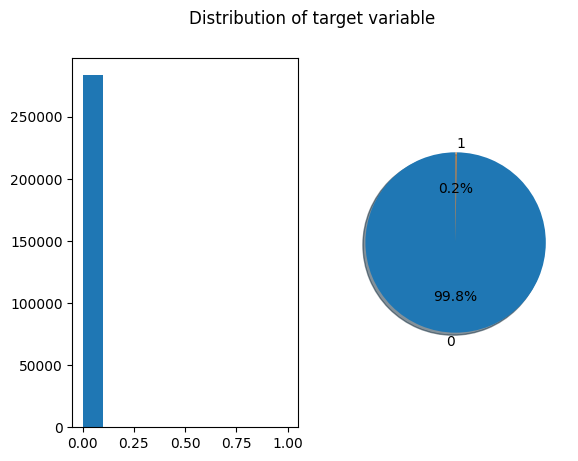

In [11]:
# Plot histogram of target variable y and also the  sliced pie chart and use orange color
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Distribution of target variable')
ax1.hist(df['class_bool'])
# ax1.set_title('Distribution of target variable')
# use orange color for pie
ax2.pie(df['class_bool'].value_counts(), labels = df['class_bool'].unique(), autopct='%1.1f%%',shadow=True, startangle=90)
plt.show()

In [12]:
print(df.describe().loc["mean",:][:5]) #  all pca columns except amount and time are having mean centered around 0
df.describe().loc["std",:][:5]
df.describe().loc["std",:][-5:]

Time    94811.077600
V1          0.005917
V2         -0.004135
V3          0.001613
V4         -0.002966
Name: mean, dtype: float64


,std
V26,0.482053
V27,0.395744
V28,0.328027
Amount,250.399437
class_bool,0.040796


### Visualize all of the plots and also the corelations between the components or any feature engineering steps needed.

In [14]:
# Do plots of all numerical continuous features against the target columns box plot , violin  plot , individual distributions , corelation heatmap, time and Amount based plots against the target variable y
df.head(1)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,class_bool
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,False,0


###**Due to extreme class imbalance, the Frequency  is plotted in logarithmic scale on Y -acis to show the  distribution against time**

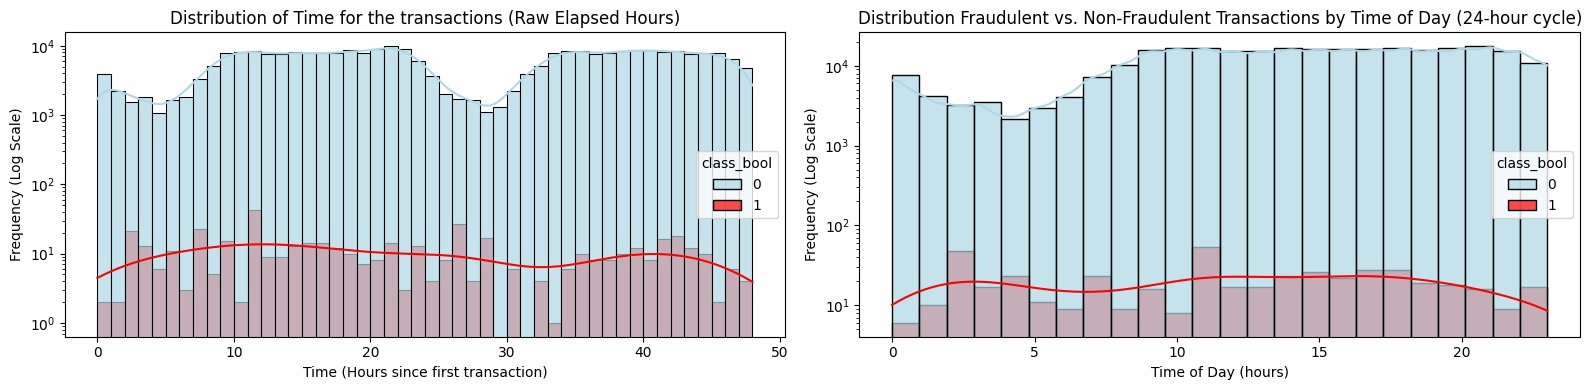

In [28]:
# Reference date is taken as Jan 1 , 2013 suppose , there are 86,400 seconds in a day, and 10 am = 36000 ,  11 pm = 82800.
# Label the xticks as approx hours of day by dividing the "time" column by 3600 - use floor function
df['time_hours'] = df['Time'] / 3600

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4)) # Adjust figsize for two plots side by side

# Define a custom palette to make fraud (1) visible in red
custom_hist_palette = {0: 'lightblue', 1: 'red'}

# First plot on ax1: Distribution of raw time (elapsed seconds)

sns.histplot(data=df, bins=48, hue='class_bool', kde=True, x='time_hours', alpha=0.7, palette=custom_hist_palette, ax=ax1)
ax1.set_title('Distribution of Time for the transactions (Raw Elapsed Hours)')
ax1.set_xlabel('Time (Hours since first transaction)')
ax1.set_ylabel('Frequency (Log Scale)')
ax1.set_yscale('log', base=10) # Apply log scale directly on the y-axis

# Calculate time_hours for 24-hour cycle for the second plot
df['time_hours'] = df['Time'] / 3600
df['time_hours'] = df['time_hours'].apply(lambda x  : int(x)%24)

# Second plot on ax2: Distribution of 24-hour cycle time
sns.histplot(data=df, bins=24, hue='class_bool', x='time_hours', alpha=0.7, palette=custom_hist_palette,
             linewidth=1, # Add linewidth for prominence
             kde=True, # Add KDE to show density more clearly
             ax=ax2
            )
ax2.set_title('Distribution Fraudulent vs. Non-Fraudulent Transactions by Time of Day (24-hour cycle)')
ax2.set_xlabel('Time of Day (hours)') # Changed label for clarity
ax2.set_ylabel('Frequency (Log Scale)')
ax2.set_yscale('log', base=10) # Apply log scale directly on the y-axis

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

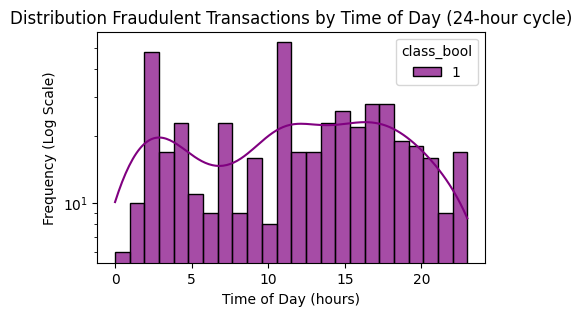

In [29]:
# Plot distribution of only fraud instances by time_hours
fig, ax = plt.subplots(figsize=(5, 3))
sns.histplot(data=df[df['class_bool'] == 1], bins=24, hue='class_bool', x='time_hours', alpha=0.7,
             palette={0: 'darkred', 1: 'purple'},
             linewidth=1, # Add linewidth for prominence
             kde=True, # Add KDE to show density more clearly
             ax=ax
            )
ax.set_title('Distribution Fraudulent Transactions by Time of Day (24-hour cycle)')
ax.set_xlabel('Time of Day (hours)') # Changed label for clarity
ax.set_ylabel('Frequency (Log Scale)')
ax.set_yscale('log', base=10) # Apply log scale directly on the y-axis
plt.show()
# There is no clear trend of fraud cases being exceptionally high or low as such wrt time

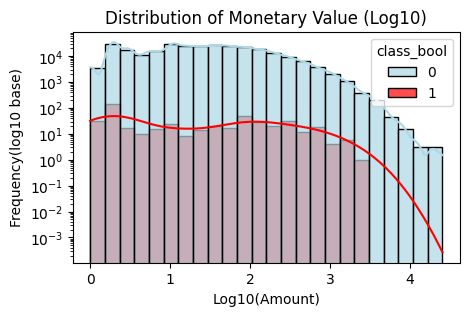

In [46]:
#  Do a log transform and create a new column log_amount
df['log_amount'] = np.log10(df['Amount'] + 1)
# Plot the same now

fig, ax = plt.subplots(figsize=(5,3))
custom_hist_palette = {0: 'lightblue', 1: 'red'} # Consistent palette
sns.histplot(data=df, bins=24, hue='class_bool', x='log_amount', alpha=0.7,
             linewidth=1, palette=custom_hist_palette, kde=True, ax=ax)
ax.set_title('Distribution of Monetary Value (Log10)')
ax.set_xlabel('Log10(Amount)')
ax.set_ylabel('Frequency(log10 base)')
# apply sqrt for y -axis
ax.set_yscale('log', base=10)
plt.show()

### **4. Feature Engineering**

Creating high-quality features can significantly improve the model's performance.

No categoral features due to PCA transformation.

For numerical features, transformation is not mandatory, but it is recommended. Normalizing or standardizing numerical features can improve the model's accuracy and stability, especially when variables have very different magnitudes of values. We will use StandardScaler

Handling missing values: Fortunately, no missing values found , 10 duplicates wer removed though.

**Feature selection**: As we saw that having raw values of time is not so useful but to engineer a new time column representing the hour is more useful, hence we would drop the 'time' column but retain the newly created column called

**"time_hours"** because as per the plots above, clearly the transactions have direct relation with the day times vs night times and so are the fraud instances are temporal in nature to some extent.

**Transaction Amount** We also saw that vast majority of transactions are lower in amounts with only a handful towards maximum causing left skewness, prompting us to engineer a new feature called "log_amount"



### **Feature Engineering - Time Component**

Converting the cyclical 'Time' feature into sinusoidal components ('hour_sin', 'hour_cos') helps the model capture cyclical patterns (e.g., transactions peaking at certain hours) without implying a false linear relationship. We'll also drop the original 'Time' column as it's replaced by these new features.

In [47]:
# Calculate 'Hour' from the 'Time' column (in seconds) for sinusoidal transformation.
# we would reate sinusoidal features for the hour of the day , to take care of the cyclical natture of time othewise [1-24] would be treated as linearly weighted values which is incorrect .
# This can be helpful for tree based models like XGBoost  which fail to understand the 24 hour format and may not consider 23:hours 11 pm and 00:00 hours midnight are next to each other .

df['Hour'] = (df['Time'] / 3600).astype(int) % 24
df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24.0)
df = df.drop(columns=['Hour', 'time_hours'], errors='ignore')
display(df[['hour_sin', 'hour_cos']].head())

,hour_sin,hour_cos
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0


In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'class_bool', 'log_amount', 'hour_sin', 'hour_cos'],
      dtype='object')

In [11]:
# Prepare X and y for modeling.

# 'Amount' is also dropped as 'log_amount' is intended to be used as a feature. Drop Time and hour as well
X = df.drop(columns=['Class', 'class_bool', 'Amount', 'Time'])
y = df['class_bool']

# Print shape of X and y
print(X.shape, y.shape)

df.columns

(283726, 31) (283726,)


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'class_bool', 'log_amount', 'hour_sin', 'hour_cos'],
      dtype='object')

After this analysis, we plot a heatmap to get a coloured
representation of the data and to study the correlation between
out predicting variables and the class variable. This heatmap is
shown below:

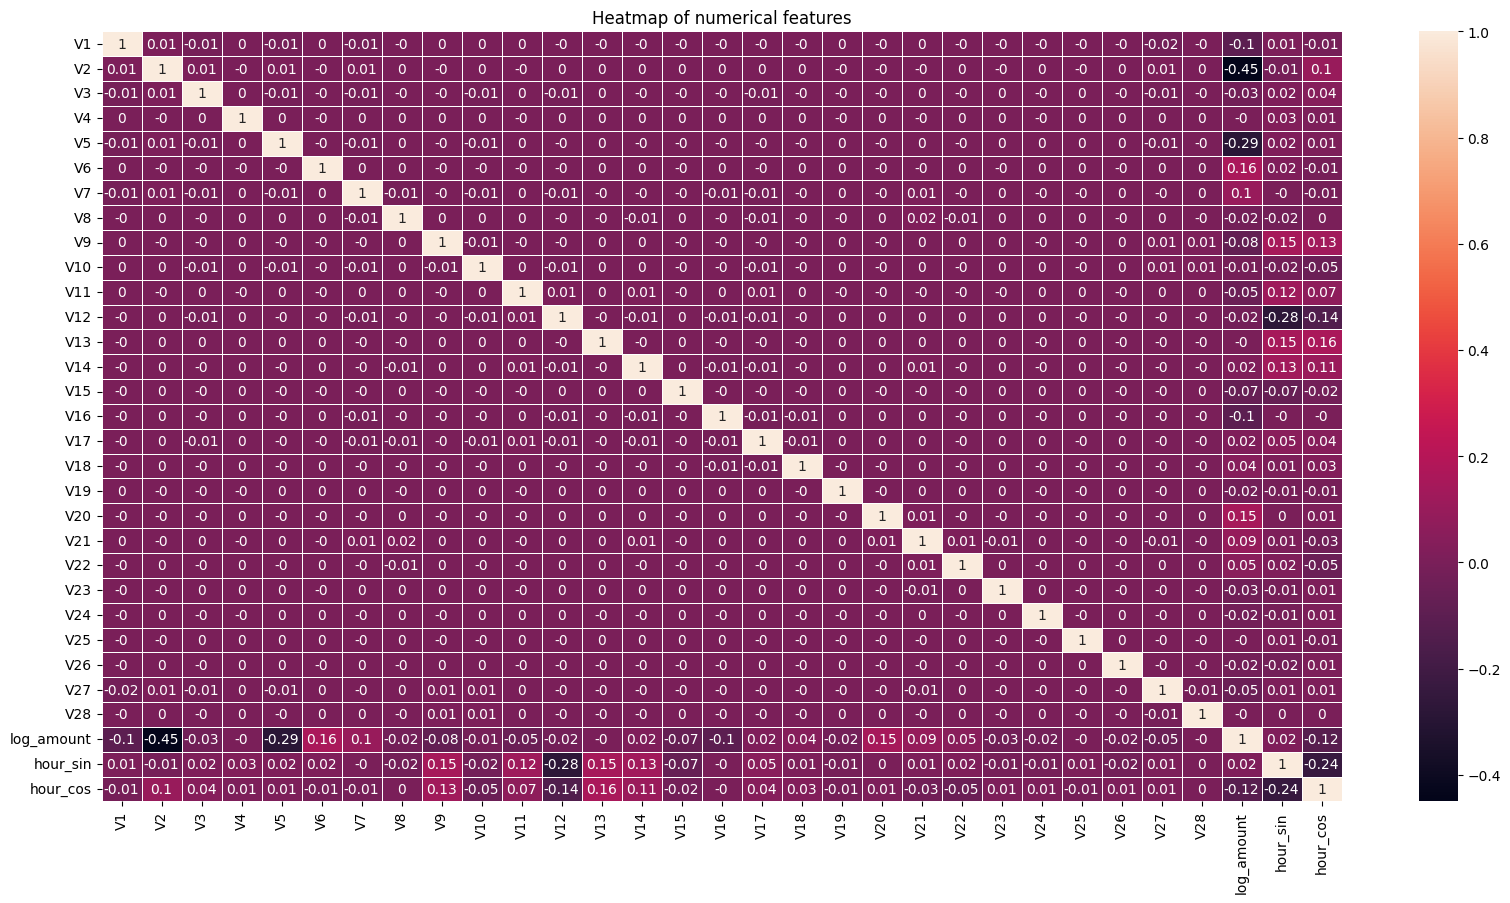

In [ ]:
# Plot heatmap of numerical columns to see if there is some multicollinearity
# 1. Select only numerical features
numeric_df = X.select_dtypes(include=['number'])
# 2. Compute the correlation matrix
corr_matrix = numeric_df.corr()
plt.figure(figsize=(20, 10))
#2. Round off to 2 dps only
sns.heatmap(corr_matrix.round(2), annot=True, linewidths=0.5)
plt.title("Heatmap of numerical features")
plt.show()
# No multicollinearity which is good sign for regression models like LogisticRegression, for better model stability.

### Visualize distribution of selected PCA components vs. target class

While interpreting individual PCA components can be challenging, visualizing their distributions across the target classes can reveal patterns. We'll focus on a few V-columns that showed some correlation with `time_hours` or `log_amount` (e.g., V2, V5, V6, V12) to see if they differentiate between fraud and non-fraud transactions.

In [ ]:
# Scatter plots for class sepration in 2D - asuming that PC1, PC2 etc are ordered as v1,v2 etc in terms of retaining the maximum variance.
# We took some random pca components in pair to see indication of class separation and can see patterns for few of them explained below.

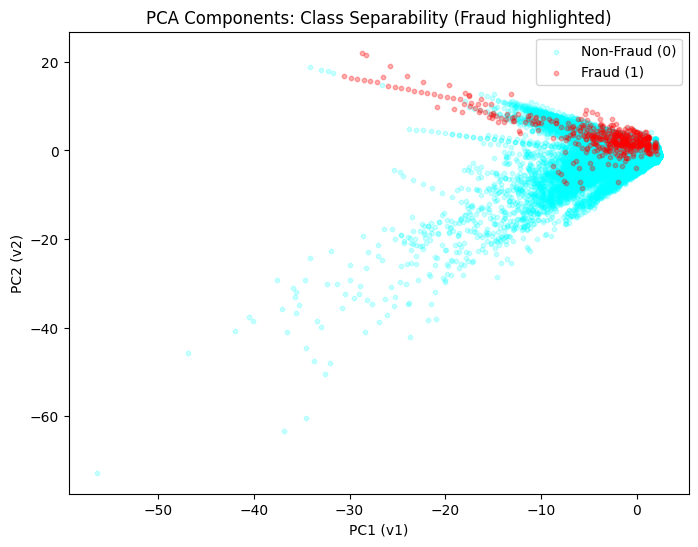

In [53]:
import matplotlib.pyplot as plt

# Create a figure
plt.figure(figsize=(8, 6))

# Plot Non-Fraud (class 0)
plt.scatter(df[df['class_bool'] == 0]['V1'], df[df['class_bool'] == 0]['V2'],
            color='cyan', alpha=0.2, s=10, label='Non-Fraud (0)') # Reduced alpha, smaller size

# Plot Fraud (class 1)
plt.scatter(df[df['class_bool'] == 1]['V1'], df[df['class_bool'] == 1]['V2'],
            color='red', alpha=0.3, s=10, marker='o', label='Fraud (1)') # Red color, larger 'o' marker, higher brightness

plt.xlabel("PC1 (v1)")
plt.ylabel("PC2 (v2)")
plt.title("PCA Components: Class Separability (Fraud highlighted)")
plt.legend()
plt.show()

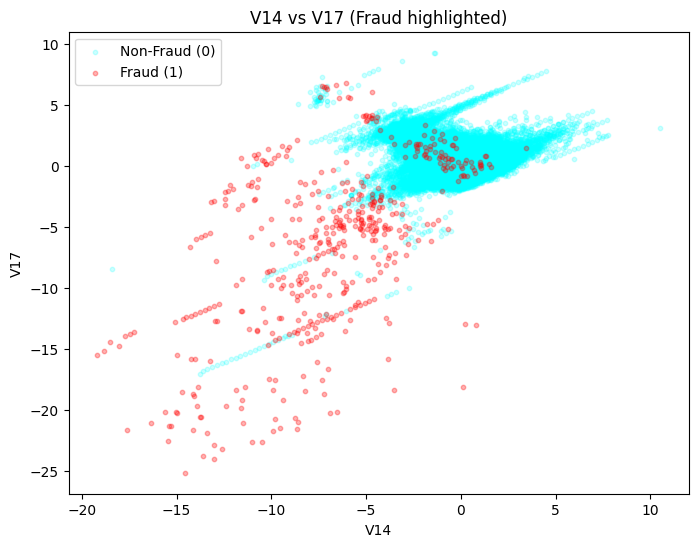

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# Plot Non-Fraud (class 0)
plt.scatter(df[df['class_bool'] == 0]['V14'], df[df['class_bool'] == 0]['V17'],
            color='cyan', alpha=0.2, s=10, label='Non-Fraud (0)') # Reduced alpha, smaller size

# Plot Fraud (class 1)
plt.scatter(df[df['class_bool'] == 1]['V14'], df[df['class_bool'] == 1]['V17'],
            color='red', alpha=0.3, s=10, marker='o', label='Fraud (1)') # Red color, larger 'o' marker, higher brightness

plt.xlabel("V14") # Add labels for clarity
plt.ylabel("V17") # Add labels for clarity
plt.title("V14 vs V17 (Fraud highlighted)")
plt.legend()
plt.show()

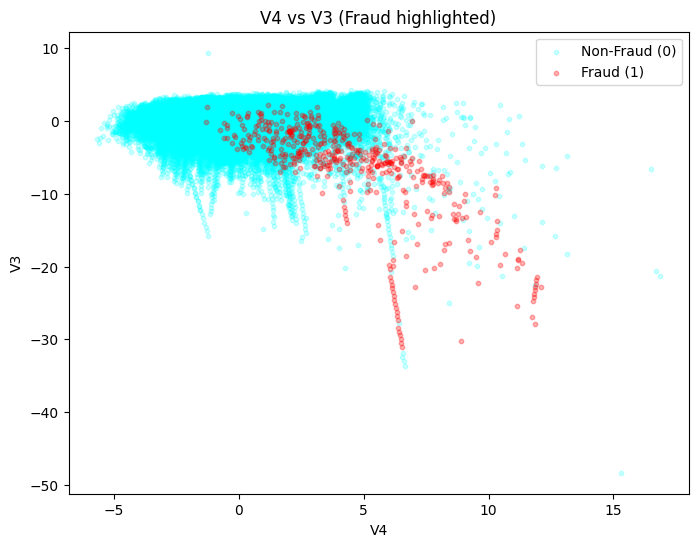

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# Plot Non-Fraud (class 0)
plt.scatter(df[df['class_bool'] == 0]['V4'], df[df['class_bool'] == 0]['V3'],
            color='cyan', alpha=0.2, s=10, label='Non-Fraud (0)') # Reduced alpha, smaller size

# Plot Fraud (class 1)
plt.scatter(df[df['class_bool'] == 1]['V4'], df[df['class_bool'] == 1]['V3'],
            color='red', alpha=0.3, s=10, marker='o', label='Fraud (1)') # Red color, larger 'o' marker, higher brightness

plt.xlabel("V4")
plt.ylabel("V3")
plt.title("V4 vs V3 (Fraud highlighted)")
plt.legend()
plt.show()

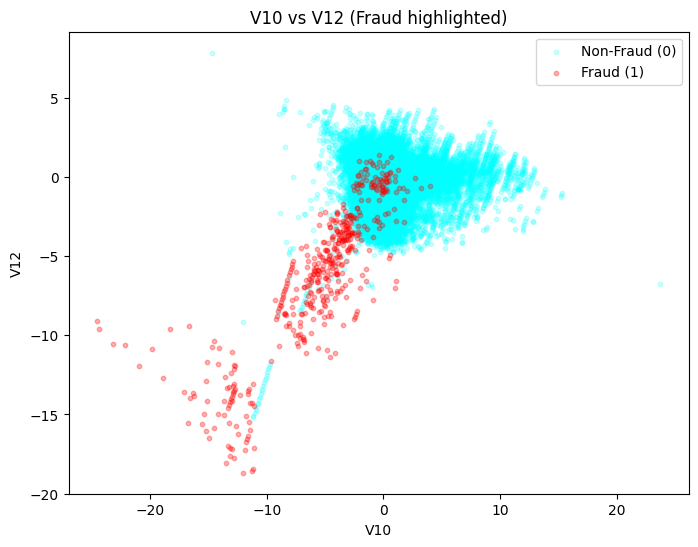

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# Plot Non-Fraud (class 0)
plt.scatter(df[df['class_bool'] == 0]['V10'], df[df['class_bool'] == 0]['V12'],
            color='cyan', alpha=0.2, s=10, label='Non-Fraud (0)') # Reduced alpha, smaller size

# Plot Fraud (class 1)
plt.scatter(df[df['class_bool'] == 1]['V10'], df[df['class_bool'] == 1]['V12'],
            color='red', alpha=0.3, s=10, marker='o', label='Fraud (1)') # Red color, larger 'o' marker, higher brightness
plt.xlabel("V10")
plt.ylabel("V12")
plt.title("V10 vs V12 (Fraud highlighted)")
plt.legend()
plt.show()

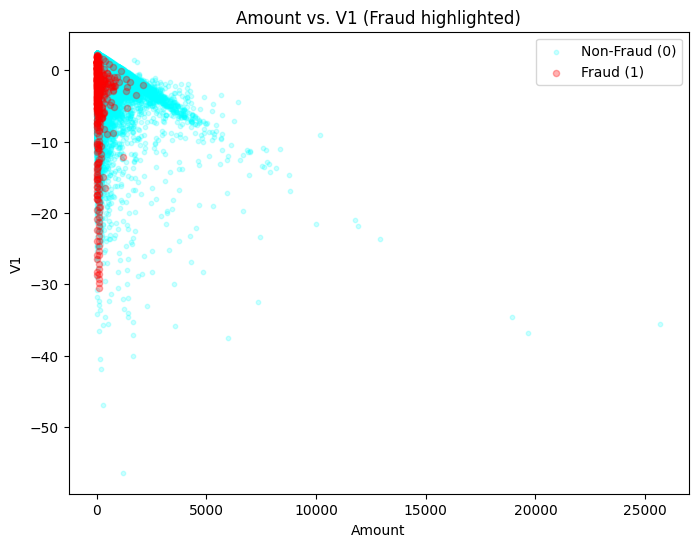

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df[df['class_bool'] == 0]['Amount'], df[df['class_bool'] == 0]['V1'],
            color='cyan', alpha=0.2, s=10, label='Non-Fraud (0)') # Reduced alpha, smaller size
plt.scatter(df[df['class_bool'] == 1]['Amount'], df[df['class_bool'] == 1]['V1'],
            color='red', alpha=0.3, s=20, marker='o', label='Fraud (1)') # Red color, larger 'o' marker, higher brightness
plt.xlabel("Amount")
plt.ylabel("V1")
plt.title("Amount vs. V1 (Fraud highlighted)")
plt.legend()
plt.show()

In [18]:
df.groupby('class_bool')['Amount'].describe()# this shows that the amount of fraud transactions happening was not directly related with higher transaction amount
# making fraud detection even more difficult as they would be lurking within normal transactions .

,count,mean,std,min,25%,50%,75%,max
class_bool,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


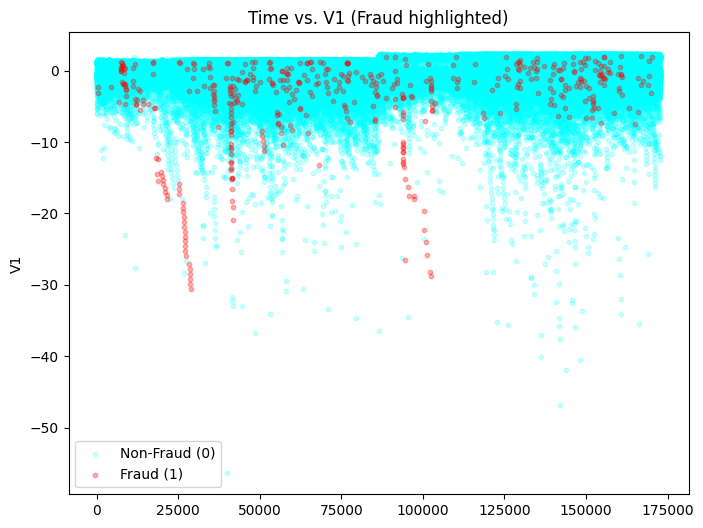

In [68]:
# Temporal features have some predictive power and become an important feature for further feature engineering .
plt.figure(figsize=(8, 6))

plt.scatter(df[df['class_bool'] == 0]['Time'], df[df['class_bool'] == 0]['V1'],
            color='cyan', alpha=0.2, s=10, label='Non-Fraud (0)') # Reduced alpha, smaller size
plt.scatter(df[df['class_bool'] == 1]['Time'], df[df['class_bool'] == 1]['V1'],
            color='red', alpha=0.3, s=10, marker='o', label='Fraud (1)') # Red color, larger 'o' marker, higher brightnessplt.xlabel("Time")

plt.ylabel("V1")
plt.title("Time vs. V1 (Fraud highlighted)")
plt.legend()
plt.show()

###**Train Test split**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,random_state=42)# Print the sizes
# check if stratify got the desired results for a consistent distribution
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

class_bool
0    0.998335
1    0.001665
Name: proportion, dtype: float64
class_bool
0    0.998326
1    0.001674
Name: proportion, dtype: float64


In [ ]:
y_train.value_counts()

,count
class_bool,
0,226602
1,378


### 5. Data preprocessing

In [23]:
# 1. Define transformers for different column types - we will keep imputers as it is harmless and possibility of unavailable values for future, as a good practice.
# Scale the data for time and amount as they have great variations hence model should not be confused.
num_columns = X.select_dtypes(include=['int64', 'float64']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())#('scaler', MinMaxScaler()) avoiding MM scaler due to big variations in time column .
])

# 2. Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_transformer', numeric_transformer,num_columns)
    ]
)

**Synthetic Minority Oversampling (SMOTE)**

Due to extreme class imbalance, SMOTE would be used to augment synthetic fraud cases for the model to have a more balanced split of 2 classes (fraud vs non-fraud) only on the training data to avoid data leakage via pipeline.

Since synthesized data can introduce noise and this is a classification problem, some algorithms may even perform poorly with sampling , hence for each of the listed models above , we would run with and w/o sampling .

IMP NOTE - When SMOTE is defined as a step in the pipeline , SMOTE step is bypassed during prediction to avoid data leakage

**Show the distribution of class Imbalance before and after SMOTE even though we would use Pipeline later**

This is to demonstrate how SMOTE would be fillers for the models to learn on the traning data by imputing syntehtic samples by amplifying the minority class which is the positive class in the case of fraud detection .

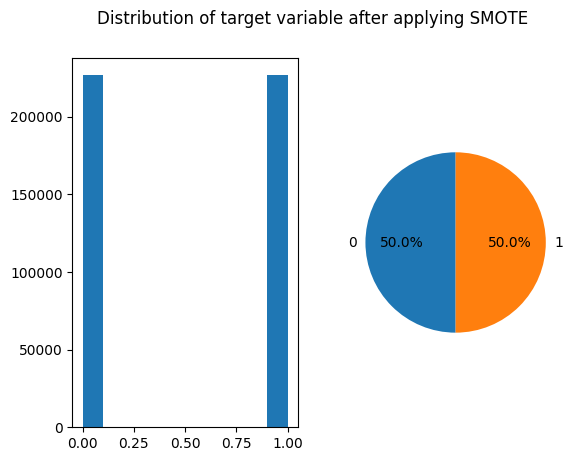

In [24]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
# Plot histogram of target variable y and also the  sliced pie chart and use orange color
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Distribution of target variable after applying SMOTE')
ax1.hist(y_resampled)
# use orange color for pie
ax2.pie(y_resampled.value_counts(), labels = y_resampled.unique(), autopct='%1.1f%%',startangle=90)
plt.show()

### **5. Modelling**

##A Noskills Model (Dummy classifier)
Before we build our first experimental model even, we want to establish a noskills classifier model .

In [ ]:
# Build a dummy classifier
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)

# Create the final imblearn Pipeline

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', dummy_clf)
])

# 4. Fit the pipeline
# SMOTE will only be applied during .fit(), not during .predict()
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'log_amount',
       'hour_sin', 'hour_cos'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', DummyClassifier(strategy='most_frequent'))])

Baseline Dummy model (test):
Accuracy: 0.9983258731892997
Precision: 0.0
recall: 0.0
F1: 0.0
Confusion matrix:
 [[56651     0]
 [   95     0]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.00      0.00      0.00        95

    accuracy                           1.00     56746
   macro avg       0.50      0.50      0.50     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.5


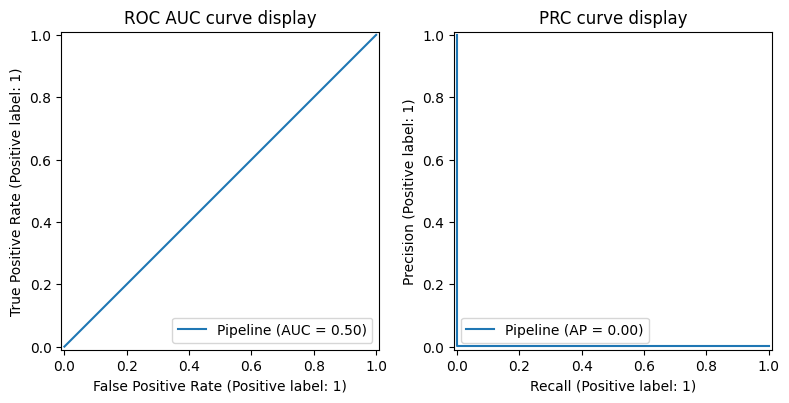

In [ ]:
y_dummy_pred = pipeline.predict(X_test)
baseline_proba = pipeline.predict_proba(X_test)[:, 1]
print("Baseline Dummy model (test):")
print("Accuracy:", accuracy_score(y_test, y_dummy_pred))

#Ignore division by 0- add to all of the scores formulae
print("Precision:", precision_score(y_test, y_dummy_pred, zero_division=0))
print("recall:", recall_score(y_test, y_dummy_pred , zero_division=0))
print("F1:", f1_score(y_test, y_dummy_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_dummy_pred))
print("Classification report:\n", classification_report(y_test, y_dummy_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, baseline_proba))

#Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax = ax1)
ax1.set_title("ROC AUC curve display")
PrecisionRecallDisplay.from_estimator(pipeline, X_test, y_test, ax =ax2)
ax2.set_title("PRC curve display")
plt.tight_layout()
plt.show()

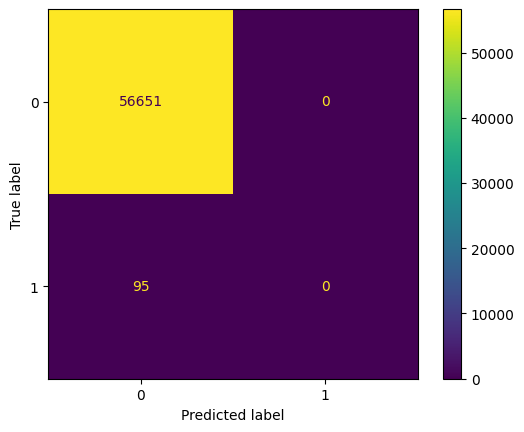

In [ ]:
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)
plt.show()

###**Supervised algorithms**
**Logistic Regression**

In [ ]:
lr_model = LogisticRegression(random_state=42, max_iter=10000)
# Create the final imblearn Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', lr_model)
])

print(f"Fitting LR model...at ", datetime.now(), " UTC")
start_time = timer()
lr_pipeline.fit(X_train, y_train)
lr_y_preds=lr_pipeline.predict(X_test)
train_time_model = timer() - start_time

# Print number of iterations using model.n_iter_ and time taken to train
print("Training time:", train_time_model)
print("Number of iterations for gradient descent to coverge:", lr_pipeline.named_steps['classifier'].n_iter_)

Fitting LR model...at  2026-06-01 12:21:20.823308  UTC
Training time: 6.850267107000036
Number of iterations for gradient descent to coverge: [24]


Logistic Regression model (train):
Accuracy: 0.9735263018768173
Precision: 0.05514299257386633
recall: 0.9232804232804233
F1: 0.10407037423587297
Confusion matrix:
 [[220622   5980]
 [    29    349]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99    226602
           1       0.06      0.92      0.10       378

    accuracy                           0.97    226980
   macro avg       0.53      0.95      0.55    226980
weighted avg       1.00      0.97      0.99    226980

ROC-AUC: 0.9885419925357789


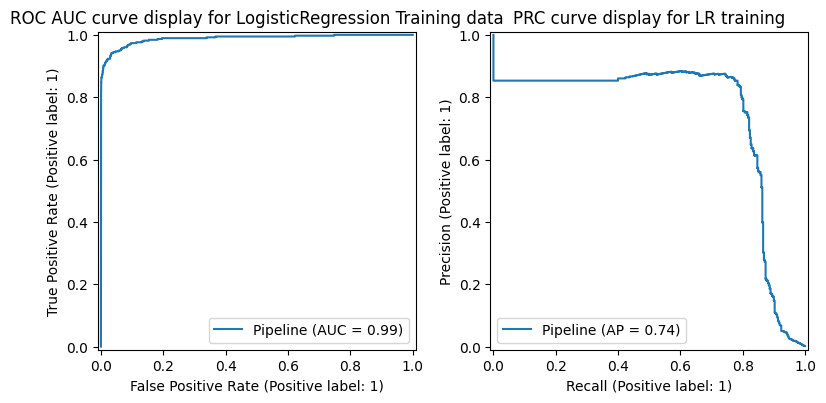

In [ ]:
# PLot the accuracy , confusion matrix and the ROC plots including precision recall curve , very important for balanced train dataset
lr_proba = lr_pipeline.predict_proba(X_train)[:, 1]
lr_y_train_preds=lr_pipeline.predict(X_train)
print("Logistic Regression model (train):")
print("Accuracy:", accuracy_score(y_train, lr_y_train_preds))

print("Precision:", precision_score(y_train, lr_y_train_preds))
print("recall:", recall_score(y_train, lr_y_train_preds))
print("F1:", f1_score(y_train, lr_y_train_preds, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_train, lr_y_train_preds))
print("Classification report:\n", classification_report(y_train, lr_y_train_preds))
print("ROC-AUC:", roc_auc_score(y_train, lr_proba))

#Create subplots  for training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
RocCurveDisplay.from_estimator(lr_pipeline, X_train, y_train, ax = ax1)
ax1.set_title("ROC AUC curve display for LogisticRegression Training data")
PrecisionRecallDisplay.from_estimator(lr_pipeline, X_train, y_train, ax =ax2)
ax2.set_title("PRC curve display for LR training")
plt.tight_layout()
plt.show()

Logistic Regression model (test):
Accuracy: 0.9726324322419201
Precision: 0.05110837438423645
recall: 0.8736842105263158
F1: 0.09656777196044211
Confusion matrix:
 [[55110  1541]
 [   12    83]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746

ROC-AUC: 0.9608806087875069


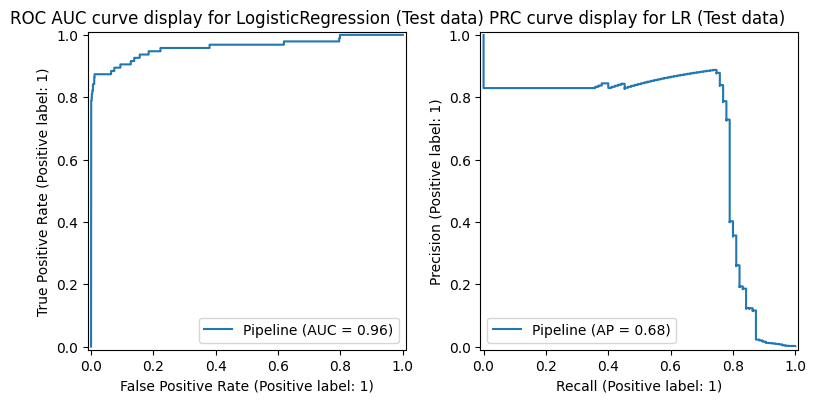

In [ ]:
# PLot the accuracy , confusion matrix and the ROC plots including precision recall curve , very important for imbalanced datasets
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
print("Logistic Regression model (test):")
print("Accuracy:", accuracy_score(y_test, lr_y_preds))

print("Precision:", precision_score(y_test, lr_y_preds))
print("recall:", recall_score(y_test, lr_y_preds))
print("F1:", f1_score(y_test, lr_y_preds, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, lr_y_preds))
print("Classification report:\n", classification_report(y_test, lr_y_preds))
print("ROC-AUC:", roc_auc_score(y_test, lr_proba))

#Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
RocCurveDisplay.from_estimator(lr_pipeline, X_test, y_test, ax = ax1)
ax1.set_title("ROC AUC curve display for LogisticRegression (Test data)")
PrecisionRecallDisplay.from_estimator(lr_pipeline, X_test, y_test, ax =ax2)
ax2.set_title("PRC curve display for LR (Test data) ")
plt.tight_layout()
plt.show()

#Prepare a table for the above metrics for later usage.

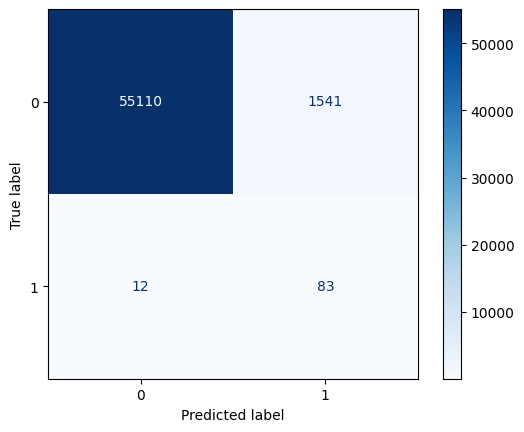

In [ ]:
ConfusionMatrixDisplay.from_estimator(lr_pipeline, X_test, y_test, cmap='Blues')
plt.show()
# Can see that almost 100 FPs are generated, which is not great.

### 6. (Evaluation)Metrics and their interpretation
---


- **True Positive (TP)**: Occurs when the model predicts that transaction is a fraud  (prediction = 1), and that is actually a fraud (actual value = 1).
- **True Negative (TN)**: Occurs when the model predicts that transaction is not a fraud (class='otherwise') (prediction = 0), and that transaction is actually not a fraud (actual value = 0).
- **False Positive (FP)**: Occurs when the model predicts the tran being fraud (prediction = 1), but that is wrong meanng it was not a fraud (actual value = 0).
- **False Negative (FN)**: Occurs when the model predicts that transaction is not a fraud (prediction = 0), but it is fraud (actual value = 1).

**IMPORTANT** This metric FN is the most important among above for the model because even a single missed detection can cause unimaginable losses. The recall score is representative of detection of actual fraud cases which we would evaluate later .

---
Lets interpret the results we got for our fine tuned LR model for now .

- **Accuracy**: The model correctly predicts the outcome in 98% of cases which is deceptively great in fraud detection. But for xtreme class imbalance in rare fraud test dataset, this is not the right metric.

- **Recall**: The model correctly identifies 100% of actual fraud cases. This is an important metric because it means no fraud cases are undetected by the model.

- **Precision**: When the model predicts that it is  a fraud, it is correct only 8% of the time. In a business context, this is critical if you want to minimize the cost of false positives, such as allocating resources and blocking legitimate transactions.

- **F1-Score**: The F1-Score balances precision and recall (Harmonic mean indicating one factor being high alone is not enough to bring the score up). A score of 0.16 indicates that the model does not strike a good balance between avoiding false predictions of frauds and not missing true frauds. In a scenario where both aspects are important, such as efficiently allocating limited resources (customer support) this metric provides a comprehensive view of the model's performance.

**AU-PRC**: This is 0.78 for test data which is ok , but not extremely great , it does produce a lot of false positives which is often the case when the number of fraud cases is extremely rare.


### **Interpretation of the above results**

Noise Amplification: Most likely what happened is given that fraudulent data point is an outlier—an isolated transaction that doesn't share characteristics with other fraud, SMOTE created synthetic data points around this noise, leading to higher False Positives and an unclear decision boundary.

ROC AUC (Receiver Operating Characteristic - Area Under the Curve): This metric plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. An ROC AUC of 1.0 indicates a perfect classifier, meaning it can distinguish between positive and negative classes perfectly without any overlap. However, for highly imbalanced datasets, the ROC curve can be misleading because the FPR doesn't effectively penalize misclassifications of the minority class.


In summary, for imbalanced datasets like fraud detection, PRC AUC is generally a more reliable and informative metric than ROC AUC because it focuses on the performance of the minority class, which is typically the class of interest. PRC AUC of 0.75 suggests an average model still .



###Do grid search on LogisticRegression
GridSearchCV would be run for identifying correct hyperparameters yielding best estimator results. Training and prediction times would also be kept in mind in deciding an optimal classifier .

In [25]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

In [26]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1,10],  # Regularization strength
        "model__solver": ["liblinear", "lbfgs"]  # Optimization algorithms
    }
   }

In [27]:
# Redefine the models- Keep SVM out for now as it is running for long time and does not complete eventually even with only a few param combinations.
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42)

}
models.items()

dict_items([('Logistic Regression', LogisticRegression(max_iter=2000, random_state=42))])

In [ ]:
from datetime import datetime
# Perform cross validation using grid search , use F1 scoring as this is a classfication problem and we intend to find a balance between precision and recall.
# Reason is that we want to detect as many potential customers as possible without missing many, while
# also avoiding reaching out unnecessarily to customers for false alarms and annoy them
from timeit import default_timer as timer

best_models = {}
results_cv = []
for name, model in models.items():
    # Include SMOTE in the pipeline for GridSearchCV
    cvpipe = Pipeline(steps=[("preprocess", preprocessor), ("smote", SMOTE(random_state=42)), ("model", model)])
    grid = GridSearchCV(cvpipe, param_grid=param_grids[name], scoring="f1", cv=cv, n_jobs=4)
    start_time = timer()
    print(f"Tuning {name}...at ", datetime.now(),  " UTC")
    grid.fit(X_train, y_train)
    train_time_model = timer() - start_time
    best_models[name] = grid.best_estimator_

    # Compute performance metrics on train and test sets
    # Predict classes
    y_tr_pred = grid.best_estimator_.predict(X_train)
    y_te_pred = grid.best_estimator_.predict(X_test)

    # Store results
    results_cv.append({"model": f"Tuned {name}", "best_f1_cv": grid.best_score_, "best_params": grid.best_params_, "Train Time": train_time_model,
        'Train Accuracy': accuracy_score(y_train, y_tr_pred),
        'Train F1': f1_score(y_train, y_tr_pred),
        'Train Recall': recall_score(y_train, y_tr_pred),
        'Train Precision': precision_score(y_train, y_tr_pred),

        'Test Accuracy': accuracy_score(y_test, y_te_pred),
        'Test F1': f1_score(y_test, y_te_pred),
        'Test Recall': recall_score(y_test, y_te_pred),
        'Test Precision': precision_score(y_test, y_te_pred)
    })

results_cv_df = pd.DataFrame(results_cv).sort_values("best_f1_cv", ascending=False).reset_index(drop=True)
display(results_cv_df)

Tuning Logistic Regression...at  2026-06-01 12:21:30.502576  UTC


In [ ]:
results_cv_df.sort_values(by="best_f1_cv", ascending=False, inplace=True)
results_cv_df

,model,best_f1_cv,best_params,Train Time,Train Accuracy,Train F1,Train Recall,Train Precision,Test Accuracy,Test F1,Test Recall,Test Precision
0,Tuned Logistic Regression,0.103,"{'model__C': 0.01, 'model__solver': 'liblinear'}",118.137788,0.974117,0.106192,0.92328,0.056336,0.973425,0.099164,0.873684,0.052565


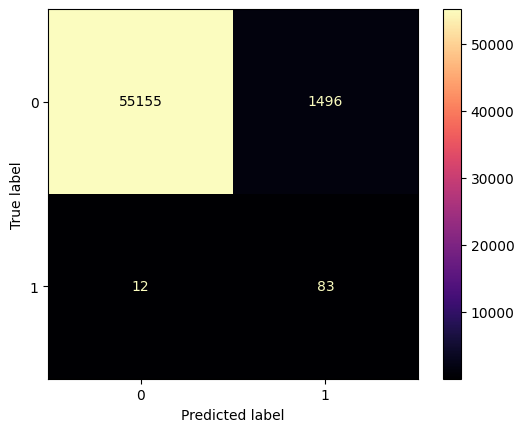

In [ ]:
ConfusionMatrixDisplay.from_estimator(best_models["Logistic Regression"], X_test, y_test, cmap='magma')
plt.show()

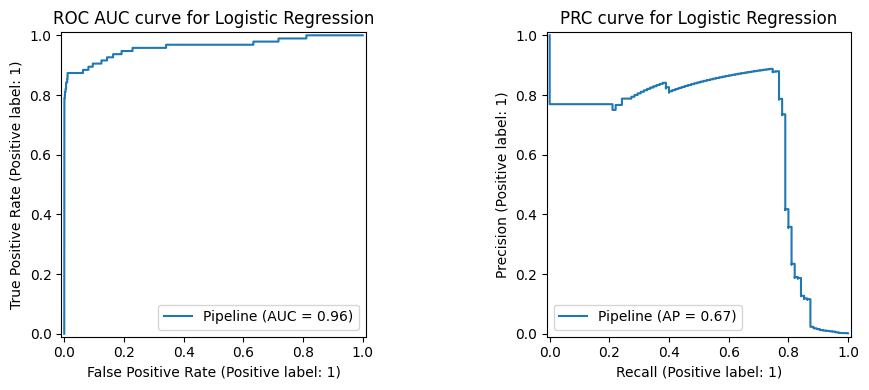

In [ ]:
#Display the AUPRC and ROC for the best estimator in subplots Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) # Reduced figsize for side-by-side plots
RocCurveDisplay.from_estimator(best_models["Logistic Regression"], X_test, y_test, ax=ax1)
ax1.set_title("ROC AUC curve for Logistic Regression")
PrecisionRecallDisplay.from_estimator(best_models["Logistic Regression"], X_test, y_test, ax=ax2)
ax2.set_title("PRC curve for Logistic Regression")
plt.tight_layout()
plt.show()

**NEW**

SMOTE did not give desired results with respect to False positives, hence try with Borderline SMOTE and class weights .

**Borderline SMOTE** - Augments minority points around expected decision boundary instead of across the whole space .
###**Borderline SMOTE**
Borderline SMOTE analyzes the surroundings of each minority point using th(KNN) algorithm:

*Safe Points*: Minority points surrounded mostly by other minority points. The algorithm ignores these.

*Noise Points*: Minority points surrounded entirely by majority points. These are treated as outliers and ignored to prevent creating bad data.

*Danger Points*: Minority points that are on the boundary, having roughly an equal mix of majority and minority neighbors.The algorithm selectively generates synthetic samples only from these Danger Points. By adding new data right along the decision boundary, it trains the model to recognize where the classes separate, directly improving precision and recall.

In [ ]:
# Tune the Logistic regression again using grid search but using Borderline SMOTE and class weights now
from sklearn.utils.class_weight import compute_class_weight
# import borderline smote
from imblearn.over_sampling import BorderlineSMOTE

#class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

best_models = {}
results_bs_cv = []
for name, model in models.items():
    # Include SMOTE in the pipeline for GridSearchCV
    cvpipe = Pipeline(steps=[("preprocess", preprocessor), ("smote", BorderlineSMOTE(random_state=42)), ("model", model)])

    grid = GridSearchCV(cvpipe, param_grid=param_grids[name], scoring="f1", cv=cv, n_jobs=4)
    start_time = timer()
    print(f"Tuning {name}...at ", datetime.now(),  " UTC")
    grid.fit(X_train, y_train)
    train_time_model = timer() - start_time
    best_models[name] = grid.best_estimator_

    # Compute performance metrics on train and test sets
    # Predict classes
    y_tr_pred = grid.best_estimator_.predict(X_train)
    y_te_pred = grid.best_estimator_.predict(X_test)

    # Store results
    results_bs_cv.append({"model": f"Tuned {name}", "best_f1_bs_cv": grid.best_score_, "best_params": grid.best_params_, "Train Time": train_time_model,
        'Train Accuracy': accuracy_score(y_train, y_tr_pred),
        'Train F1': f1_score(y_train, y_tr_pred),
        'Train Recall': recall_score(y_train, y_tr_pred),
        'Train Precision': precision_score(y_train, y_tr_pred),

        'Test Accuracy': accuracy_score(y_test, y_te_pred),
        'Test F1': f1_score(y_test, y_te_pred),
        'Test Recall': recall_score(y_test, y_te_pred),
        'Test Precision': precision_score(y_test, y_te_pred)
    })

results_bs_cv_df = pd.DataFrame(results_bs_cv).sort_values("best_f1_bs_cv", ascending=False).reset_index(drop=True)
results_bs_cv_df.sort_values(by="best_f1_bs_cv", ascending=False, inplace=True)
results_bs_cv_df


Tuning Logistic Regression...at  2026-06-01 12:23:30.351720  UTC


,model,best_f1_bs_cv,best_params,Train Time,Train Accuracy,Train F1,Train Recall,Train Precision,Test Accuracy,Test F1,Test Recall,Test Precision
0,Tuned Logistic Regression,0.451693,"{'model__C': 1, 'model__solver': 'lbfgs'}",134.123876,0.995718,0.4,0.857143,0.26087,0.995453,0.376812,0.821053,0.244514


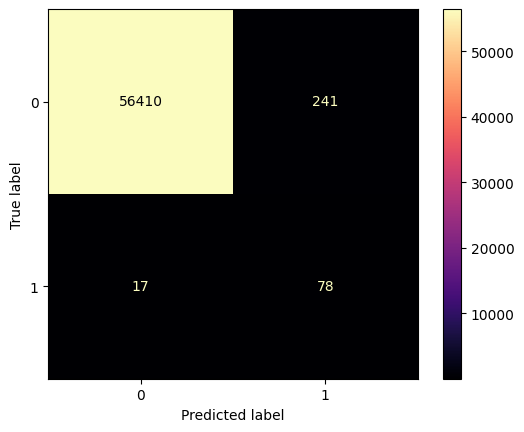

Confusion Matrix:
[[56410   241]
 [   17    78]]


In [ ]:
from sklearn.metrics import confusion_matrix

# Display the confusion matrix
ConfusionMatrixDisplay.from_estimator(best_models["Logistic Regression"], X_test, y_test, cmap='magma')
plt.show()
cm_lr = confusion_matrix(y_test, best_models["Logistic Regression"].predict(X_test))
print("Confusion Matrix:")
print(cm_lr)

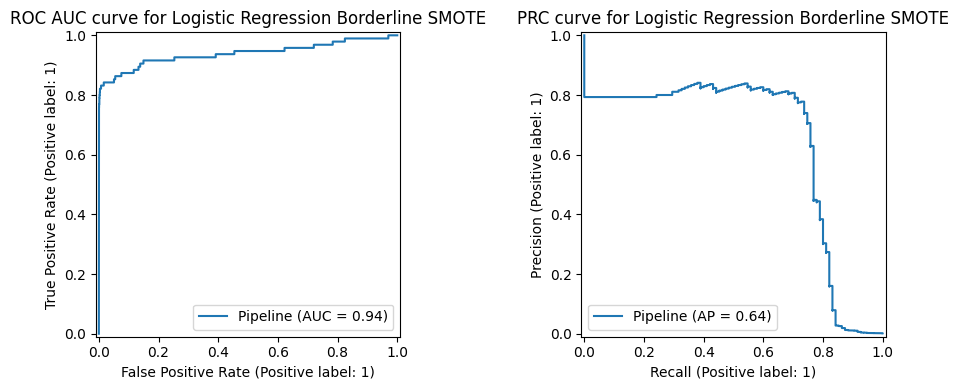

In [ ]:
#Display the AUPRC and ROC for the best estimator in subplots Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) # Reduced figsize for side-by-side plots
RocCurveDisplay.from_estimator(best_models["Logistic Regression"], X_test, y_test, ax=ax1)
ax1.set_title("ROC AUC curve for Logistic Regression Borderline SMOTE")
PrecisionRecallDisplay.from_estimator(best_models["Logistic Regression"], X_test, y_test, ax=ax2)
ax2.set_title("PRC curve for Logistic Regression Borderline SMOTE")
plt.tight_layout()
plt.show()

### Comparison of Logistic Regression Models

To determine the most effective strategy for handling class imbalance, let's compare the performance metrics of Logistic Regression with:
1.  **SMOTE** (from previous `GridSearchCV` run)
2.  **Borderline SMOTE** (from previous `GridSearchCV` run)

In [ ]:
# Extract relevant columns and rename for clarity
results_smote_lr = results_cv_df[['model', 'Test F1', 'Test Recall', 'Test Precision']].copy()
results_smote_lr['model'] = 'LR with SMOTE'

results_bs_smote_lr = results_bs_cv_df[['model', 'Test F1', 'Test Recall', 'Test Precision']].copy()
results_bs_smote_lr['model'] = 'LR with Borderline SMOTE'

# Concatenate all results into a single DataFrame
comparison_df = pd.concat([results_smote_lr, results_bs_smote_lr], ignore_index=True)

# Display the comparison table
display(comparison_df.set_index('model'))

,Test F1,Test Recall,Test Precision
model,,,
LR with SMOTE,0.099164,0.873684,0.052565
LR with Borderline SMOTE,0.376812,0.821053,0.244514


We saw that the AUPRC is not great , hence use cost based metric in the form of F4 score which weighs recall doubly important than precision , F1 score weighs them equally.

classic use in CC fraud as letting a fraud tran get away is usually more expensive than asking a user to verify by calling or texting . $$(\text{FalsePositive}).$$

$$\text{\(\beta = 4\) (\(F_{2}\)-score).}$$.

In [ ]:
# 1. Generate probabilities for the fraud class (class 1)
# y_true: actual labels (0 or 1), y_scores: predicted probabilities from logistic regression
precision, recall, thresholds = precision_recall_curve(y_test, best_models["Logistic Regression"].predict_proba(X_test)[:, 1])

# 2. Define beta weight (beta=2 prioritizes catching fraud over false alarms)
beta = 1

# 3. Calculate F-beta score for every threshold point
f_beta = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

# 4. Handle any potential NaN values from zero divisions safely
f_beta = np.nan_to_num(f_beta, nan=0.0)

# 5. Locate the index of the highest F-beta score
best_index = np.argmax(f_beta)
optimal_threshold = thresholds[best_index]
max_f_beta = f_beta[best_index]

print(f"Optimal Threshold for Fraud: {optimal_threshold:.4f}")
print(f"Maximized F2-Score: {max_f_beta:.4f}")
print(f"Resulting Precision: {precision[best_index]:.4f}, Recall: {recall[best_index]:.4f}")

Optimal Threshold for Fraud: 0.9988
Maximized F2-Score: 0.7568
Resulting Precision: 0.7778, Recall: 0.7368


## Borderline SMOTE and cost based learning does not yield good results  for Logistic Regression
1. We do see that the F1 score and Precision improve a lot with Borderline SMOTE however recall declines which is not good for fraud detection on unseen data**

2. Tuning for Optimal threshold gives recall reduced to 0.73.

In [ ]:
# Generate the confusion matrix again using the custom threshold
# 1. Get raw probabilities for the positive fraud class (column 1)
raw_probabilities = best_models["Logistic Regression"].predict_proba(X_test)[:, 1]

# 2. Apply your custom optimal threshold manually
custom_predictions = (raw_probabilities >= optimal_threshold).astype(int)

print("Confusion Matrix with Optimal Threshold:")
print(confusion_matrix(y_test, custom_predictions))

print("\nClassification Report:")
print(classification_report(y_test, custom_predictions))

# Still no better than the 12 False negatives found after grid saearch.

Confusion Matrix with Optimal Threshold:
[[56631    20]
 [   25    70]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.78      0.74      0.76        95

    accuracy                           1.00     56746
   macro avg       0.89      0.87      0.88     56746
weighted avg       1.00      1.00      1.00     56746



### Incresing d/ decreasing hyperparameter 1/C on Logistic Regression
Do note that the C is inverse of lambda , with increasing 1/C , regularization strength increases, hence shrinking the coefs of the features towards 0 .



In [ ]:
# 1. Extract the fitted Logistic Regression model from the best pipeline
fitted_lr_model = best_models["Logistic Regression"].named_steps['model']

# 2. Extract the preprocessor from the best pipeline and transform X_train and X_test using same preprocesor
preprocessor_from_pipeline = best_models["Logistic Regression"].named_steps['preprocess']
X_train_processed = preprocessor_from_pipeline.transform(X_train)
X_test_processed = preprocessor_from_pipeline.transform(X_test)

# Convert processed arrays back to DataFrame for SHAP to retain feature names
num_columns = X.columns # all numerical columns
X_train_processed_df = pd.DataFrame(X_train_processed, columns=num_columns)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=num_columns)

In [ ]:
Cs = np.linspace(0.00001  ,.5)# different cvalues of regularization parameters,larger the values , smaller amounts of regularazation (c = inverse of lambda) # default 50 samples
coef_list = []
for C in Cs:
  lgr = LogisticRegression(penalty='l1',solver='liblinear',C=C, random_state=42,max_iter=1000)
  lgr.fit(X_train_processed,y_train)
  coef_list.append(lgr.coef_[0])

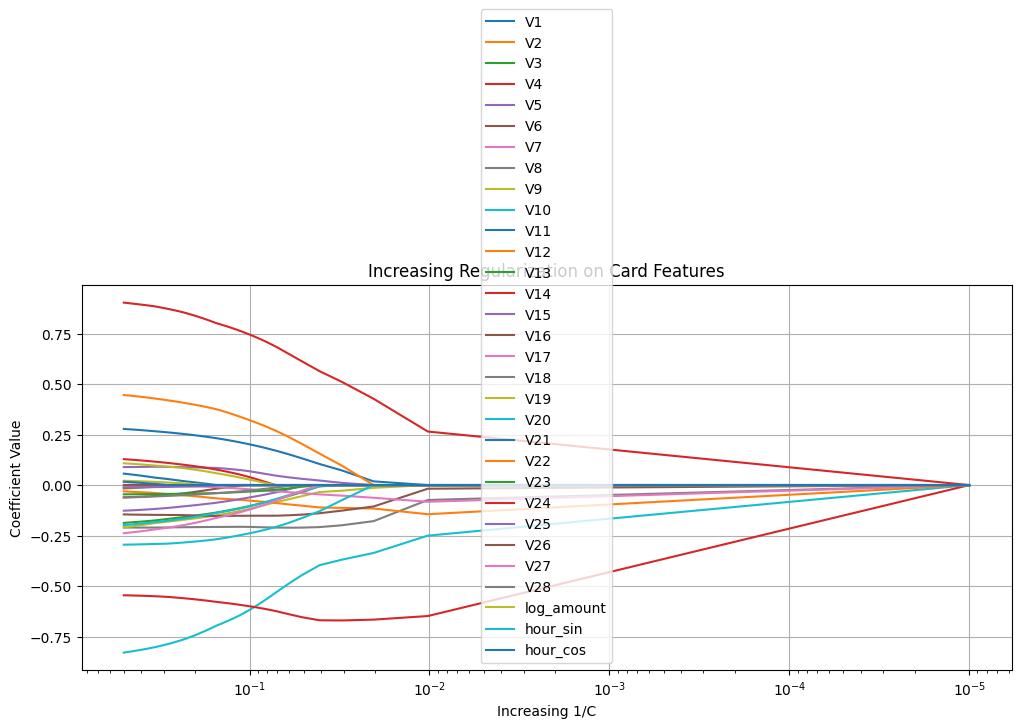

In [ ]:
# Do note that the C is inverse of lambda , with increasing 1/C , regularization strength increases,
# hence shrinking the coefs of the features towards 0 .
coef_df = pd.DataFrame (coef_list).set_index(Cs)
coef_df.columns = X.columns
plt.figure(figsize = (12, 5))
plt.semilogx(coef_df)
plt.gca().invert_xaxis()
plt.grid()
plt.legend(list(coef_df.columns));
plt.title('Increasing Regularization on Card Features')
plt.xlabel("Increasing 1/C")
plt.ylabel("Coefficient Value");


Important features that ar resistant to being pushed towards 0 due to the linear LR model with L1 regularization that effectively does feaure selection.
 [v14, v20, v17, v12, v24, v6,v16,v26 ]. We can validate the same using SelecfromModel test as well where we do see the best features overlap with the above experiment on regularization.

In [ ]:
# Using SelectFromModel for selecting best features
from sklearn.feature_selection import SelectFromModel

log_reg = LogisticRegression(C=0.1,random_state=43 ,penalty='l1',solver = 'liblinear')
selector = SelectFromModel(log_reg)
selector.fit_transform(X_train_processed,y_train)

# Get the indices of the selected features
selected_feature_indices = selector.get_support(indices=True)

# Map the indices back to the original column names from the X DataFrame
best_features = X.columns[selected_feature_indices]

### ANSWER CHECK
print(best_features)
#Index(['v3', 'v4', 'v8', 'v10', 'v12', 'v14', 'v16', 'v17', 'v21'], dtype='object')


Index(['V4', 'V5', 'V8', 'V9', 'V10', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17',
       'V20', 'V21', 'V22', 'V23', 'V24', 'V27', 'V28', 'log_amount',
       'hour_sin'],
      dtype='object')


### **SHAP Summary Plot** Plot the shap summary for feature interpretability and importance

This plot helps us understand the feature importance and how each feature impacts the model's output.

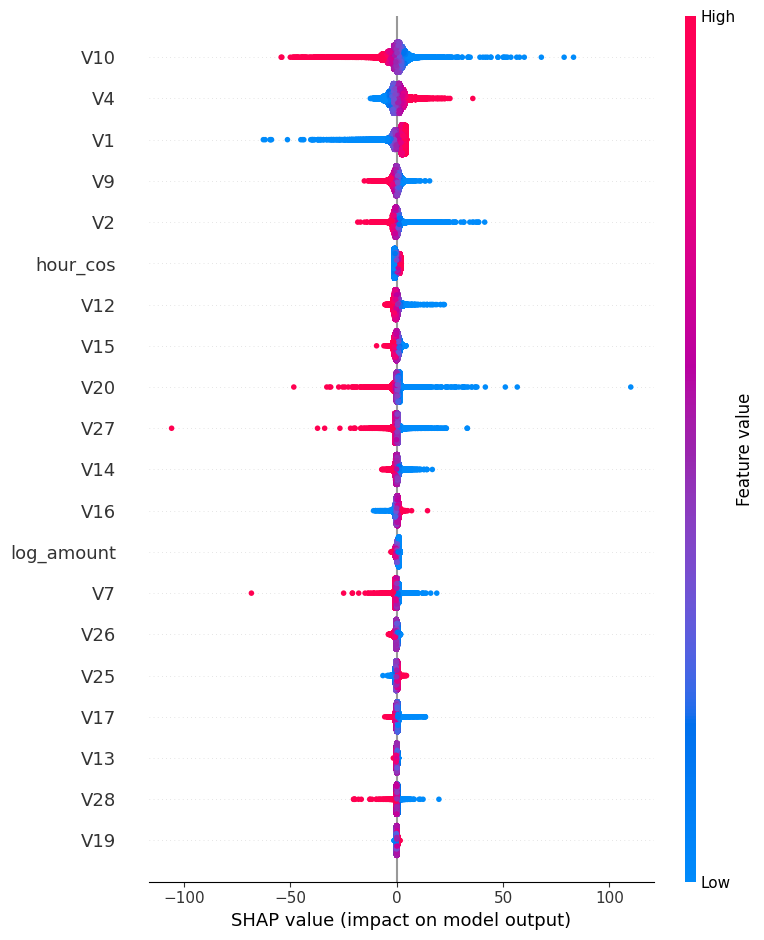

In [ ]:
import shap
# Use SHAP's LinearExplainer with the fitted model and processed training data
# The `X_train_processed_df` here acts as the background dataset for the explainer
explainer = shap.LinearExplainer(fitted_lr_model, X_train_processed_df)

# Compute SHAP values for the processed test set
shap_values = explainer.shap_values(X_test_processed_df)

# Plot the SHAP summary using the processed test set with feature names
shap.summary_plot(shap_values, X_test_processed_df)

**Observations from above SHAP plot -**

1.Feature Importance - Plot sorts the features as per their importance in making predictions in descending order. Hence , v10,v4,v24 and v6 are the most significant features in having an impact on model's predictions,  even Though PCA transformations got ordered by V1,V2...  as per retaining the maximum variance in the data.

2.Direction of impact - A positive SHAP value meaning towards right , pushes the predictions towards positive class ie 1 , while a negative value towards non-fraud .

3.For v10 as an example, red is on left , blue is on right, this implies that as the most important predictor for model, high values of this feature would push the transaction to be classified as normal , whereas lower values would tend to classify the transaction as fraud. Similarly, for other features.

This also shows that impact of when a transacton is done has some impact on frauds but not a lot as it is somehwat mid way in terms of importance.

**Important Note** We extracted the preprocessor and the best model estimator from within the pipleline but intentionally did not include the SMOTE step to avoind the feature interpretability from being influenced by synthetic samples.

### **7. Additional Insights on the above experiment with LR on feature importance**
Doing a comparision of features using pca, SHAP plot and the C-regularization plot, we can infer the relative importance of certain feature having more predictive ability when devloping complex models.




**Technical Summary - Let's summarize what we learnt**
We built the noskills classifier model to ensure that the minimum baseline model that we consider Logistic Regression outsmarts it , which it does.

---

1.We tried cv and grid search to choose optimal hyperparameter as default L2 regularization , with F1 scoring and found that the model achieves high recall but compromises on precision causing lots of false positives .

2.We try out different C values (L1 = lasso reg) with linear model and can to alrge extent validate that at 0.1 (1/C), the feature selection(shrinking some coeffs to 0) aligns with the SelectFromModel with same parameters as well.

3.We find that in spite of original features being PCA transformed, a variety of pairwaise scatter plots show above average class discrimination for outliers (fraud cases), paving the way for building complex models on these principles (explained in **"Future Work section"** at the end)

4.Accuracy is not a good measure for imbalanced datasets and hence our goal remains to maximize AUPRC score , f1 score with 100% recall to not cause any fraud cases undetected .

5.SHAP plot also show feature importance but by averaging over the iomportance of each feature per sample hence its exact set of important features slightly different from the experiment in point 2.

---

**The importance of time**
We can see that most of the transactions happend during day time and least numbers of transactions hapended during nigh This provided great temporal imputs on developing time sensitive models from recent past behaviour.

Time-Delta Computation: Models calculate the time gap between consecutive transactions to identify sudden bursts of activity, which are often indicative of fraud in real time systems even though in this dataset , we do not have enough fraud samples.

The transactions can be further broken down in days_of_week, time_of_day, weekend etc in developing more robust models.

**Location as a feature** Similarly,  GPS location of device through which transaction is being carried out need to be captured as a feaure.

---
**Borderline SMOTE**
These findings also  indicate that Borderline SMOTE does not
improve the results significantly for fraud detection in this
dataset. Despite the scarcity of fraud instances, the gener
ated synthetic data introduces noise and adversely affects
most models’ performance. Decision Trees and Random
Forest, leveraging the inherent nature of fraud occurrences
as closely related and rare events, outperform other models
in this scenario.

### **Part 2 -Final assignment submmission**
After a few weeks , we  explore plenty of other models from the list below for their ability to distinguish classes in dense data along with higher rates of detectability (high recall, F1 score and AUPRC). Instead of SMOTE, we can consider class_weights as well for appropriate model for eg - scale_pos for XGB cost_weight learning to avoid the noise we saw in the LR model bringing down precision with lots of false positives.

1. **Decision Tree** - Prone to overfit but if properly tuned , can give amazing results due to its greedy nature and splitting criterion, suited for to imbalanced data.

2. **XGBoost** - Provides massive improvement over Logistic Regression by cobining multiple weak trees and additive improvements. Pertinent for fraud detection as it prioritizes recall and reducing false positives at the same time. This is a scalable solution used in banking industry dealing with streaming and big data.

3. **Random Forest** - Tree ensemble method, by taking average of multiple trees on bootstrapped samples, reduces risk of overfitting typical of decision trees.

4. **Voting Ensemble** - An ensemble approach combining predictions from an ensemble of base estimators which perform best to balance F1.

We can explore some **Unsupervised learning** as well to find the normal pattern of transactions and isolating outliers.

5. **Isolation Forest**- Unsupervised - Fraud cases can be considered anomoalies in an otherwise normal dataset, by building mutliple trees and isolating outliers.

6. **Multi layer perceptron** - Artificial neural network to detect comlex fraud patterns through hidden layer transformations and tuned activations.

## Prepare Class Imbalance Handling Parameters
Calculate the `scale_pos_weight` for the XGBoost model to handle class imbalance.

**Reasoning**:
Calculate the ratio of negative to positive samples in `y_train` to determine the `scale_pos_weight` for XGBoost.
This parameter would be used to provide more weight to minority class due to extreme class imbalance .

This is special for XGB because it scales the gradient of the positive class means it scales the entire loss contribution of the positive class by calculatyed  factor rather than just adjusting class priors  ( ie expected prob dist of class in the training data).

In [28]:
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

print(f"Negative samples: {neg_count}")
print(f"Positive samples: {pos_count}")
print(f"Calculated scale_pos_weight for XGBoost: {scale_pos_weight}")

Negative samples: 226602
Positive samples: 378
Calculated scale_pos_weight for XGBoost: 599.4761904761905


In [29]:
# Use Decision Tree with grid search
# Redefine the models- Keep SVM out for now as it is running for long time and does not complete eventually even with only a few param combinations. Would attempt unsupervised OneClassSVM later .
from xgboost import XGBClassifier
models = {
  "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42,class_weight='balanced'), # already trained before with grid search .
  "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "SVM": SVC(random_state=42, probability=True),# to tune decision boundary and also plot AU PRC curve, need probability scores for svm
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)# to fix class imbalance using weight we defined in above function
}

###  Hyper parameter tuning and grid search on all supervised models

In [30]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01,0.1,1],  # Regularization strength
        "model__solver": ["liblinear", "lbfgs"]  # Optimization algorithms
    },
    "SVM": {
        "model__kernel": ["linear","rbf"],
        "model__C": [0.1,1],#add a small regularization and gamma also with some numerical values as well in addition to scale and auto
        "model__gamma": ["scale", 0.1, 1] # dictates the shape of the decision boundary
    },
    "Decision Tree": {
        "model__max_depth": [None, 5,10,15],  # Maximum depth of the tree
        "model__min_samples_split": [2, 5, 10] # Minimum samples required to split
    },
    # Add  grid params for RandomForest and XGBoost
    "Random Forest": {
        "model__n_estimators": [300,200],  # Number of trees in the forest
        "model__max_depth": [5,8],  # Maximum depth of each tree
        "model__min_samples_split": [2, 5],
        "model__max_features": [5] # Number of features to consider for best split
    },
    "XGBoost":{
        "model__n_estimators": [200, 300, 400],  # Number of trees in the forest
        "model__learning_rate": [0.1, 0.2,0.05],
        "model__max_depth": [3, 5, 7],  # Maximum depth of each tree
        "model__colsample_bytree": [0.8] # Subsample ratio of columns when constructing each tree meaning max , limiting here for efficienct as algo timing out on notebook .
    }

}

### Stratified Shuffle Split to  reduce training time

Create smaller training subsets for time-consuming models.

Define a function to split the training data further into a smaller set for SVM slow trainer .

We use X_train and y_train from the full train_test_split as the base.

In [31]:
from sklearn.model_selection import StratifiedShuffleSplit

def create_stratified_subsets(X, y, train_size, random_state=42):
    sss = StratifiedShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
    for train_subset_index, _ in sss.split(X, y):
        X_subset_df = X.iloc[train_subset_index].copy()
        y_subset = y.iloc[train_subset_index].copy()
    print(f"Subset X shape: {X_subset_df.shape}")
    print(f"Subset y shape: {y_subset.shape}")
    print(f"Class distribution in y_subset:\n{y_subset.value_counts(normalize=True)}")
    return X_subset_df, y_subset

In [32]:
print(f"Original X_train shape: {X_train.shape}")
print(f"Original y_train shape: {y_train.shape}")

# General subset for most models (train_size=1)
print("\nCreating general training subset (train_size=1):")  # full data for regular models taking normal time .
X_train_subset_general_df, y_train_subset_general_df = create_stratified_subsets(X_train, y_train, train_size=0.99999, random_state=42)

# Specific subset for SVM (train_size=0.1)
print("\nCreating RF and SVM-specific training subset (train_size=0.1):")
X_train_subset_svmrf_df, y_train_subset_svmrf_df = create_stratified_subsets(X_train, y_train, train_size=0.15, random_state=42)

Original X_train shape: (226980, 31)
Original y_train shape: (226980,)

Creating general training subset (train_size=1):
Subset X shape: (226977, 31)
Subset y shape: (226977,)
Class distribution in y_subset:
class_bool
0    0.998335
1    0.001665
Name: proportion, dtype: float64

Creating RF and SVM-specific training subset (train_size=0.1):
Subset X shape: (34047, 31)
Subset y shape: (34047,)
Class distribution in y_subset:
class_bool
0    0.998326
1    0.001674
Name: proportion, dtype: float64


In [33]:
# Used entire X_train effectively for faster models .
print(y_train_subset_general_df.value_counts())
y_train.value_counts()
print(y_train_subset_svmrf_df.value_counts())

class_bool
0    226599
1       378
Name: count, dtype: int64
class_bool
0    33990
1       57
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from datetime import datetime
from timeit import default_timer as timer
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import pandas as pd

best_models = {}
df_results_cv = []

for name, model in models.items():
    pipeline_steps = [("preprocess", preprocessor)]
    pipeline_steps.append(("model", model))

    cvpipe = Pipeline(steps=pipeline_steps)

    # Use appropriate subset for training to manage computation time
    #  ["Random Forest", "SVM"] instead use smaller set due to grid search crash
    if name in ["Random Forest", "SVM"]:
        current_X_train_subset_df = X_train_subset_svmrf_df
        current_y_train_subset = y_train_subset_svmrf_df
    else:
        current_X_train_subset_df = X_train_subset_general_df
        current_y_train_subset = y_train_subset_general_df

    print(f"Tuning {name}... at {datetime.now()} UTC on training size {current_X_train_subset_df.shape[0]}")
    # Using recall as the scoring metric
    grid = GridSearchCV(cvpipe, param_grids[name], scoring="recall", cv=cv, n_jobs=-1)

    start_time = timer()
    grid.fit(current_X_train_subset_df, current_y_train_subset)
    train_time_model = timer() - start_time

    best_models[name] = grid.best_estimator_

    # Evaluate metrics take whole of test data - no problem as the subsets of training data were created from X_train preventing any data leakage.
    y_tr_pred = grid.best_estimator_.predict(current_X_train_subset_df)
    y_te_pred = grid.best_estimator_.predict(X_test)

    df_results_cv.append({
        "model": f"Tuned {name}",
        "best_recall_cv": grid.best_score_,
        "best_params": grid.best_params_,
        "Train Time": train_time_model,

        'Train Accuracy': accuracy_score(current_y_train_subset, y_tr_pred),
        'Train F1': f1_score(current_y_train_subset, y_tr_pred),
        'Train Recall': recall_score(current_y_train_subset, y_tr_pred),
        'Train Precision': precision_score(current_y_train_subset, y_tr_pred),

        'Test Accuracy': accuracy_score(y_test, y_te_pred),
        'Test F1': f1_score(y_test, y_te_pred),
        'Test Recall': recall_score(y_test, y_te_pred),
        'Test Precision': precision_score(y_test, y_te_pred)
    })

# Display consolidated results
gs_results_cv_df = pd.DataFrame(df_results_cv).sort_values("best_recall_cv", ascending=False).reset_index(drop=True)
display(gs_results_cv_df)

Tuning Logistic Regression... at 2026-06-01 17:16:06.278050 UTC on training size 226977
Tuning Random Forest... at 2026-06-01 17:17:15.245636 UTC on training size 34047
Tuning SVM... at 2026-06-01 17:24:31.145212 UTC on training size 34047
Tuning Decision Tree... at 2026-06-01 18:24:29.628356 UTC on training size 226977
Tuning XGBoost... at 2026-06-01 18:31:48.170460 UTC on training size 226977


,model,best_recall_cv,best_params,Train Time,Train Accuracy,Train F1,Train Recall,Train Precision,Test Accuracy,Test F1,Test Recall,Test Precision
0,Tuned Logistic Regression,0.912654,"{'model__C': 0.1, 'model__solver': 'liblinear'}",68.519164,0.975385,0.111058,0.923280,0.059082,0.975029,0.104864,0.873684,0.055780
1,Tuned XGBoost,0.875616,"{'model__colsample_bytree': 0.8, 'model__learn...",984.988702,0.994907,0.395397,1.000000,0.246415,0.994343,0.335404,0.852632,0.208763
2,Tuned Decision Tree,0.865034,"{'model__max_depth': 5, 'model__min_samples_sp...",438.225675,0.963882,0.081971,0.968254,0.042797,0.964368,0.074176,0.852632,0.038775
3,Tuned SVM,0.807143,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",3598.115034,0.999559,0.864865,0.842105,0.888889,0.999366,0.793103,0.726316,0.873418
4,Tuned Random Forest,0.790476,"{'model__max_depth': 5, 'model__max_features':...",435.111536,0.999912,0.974359,1.000000,0.950000,0.999383,0.795322,0.715789,0.894737


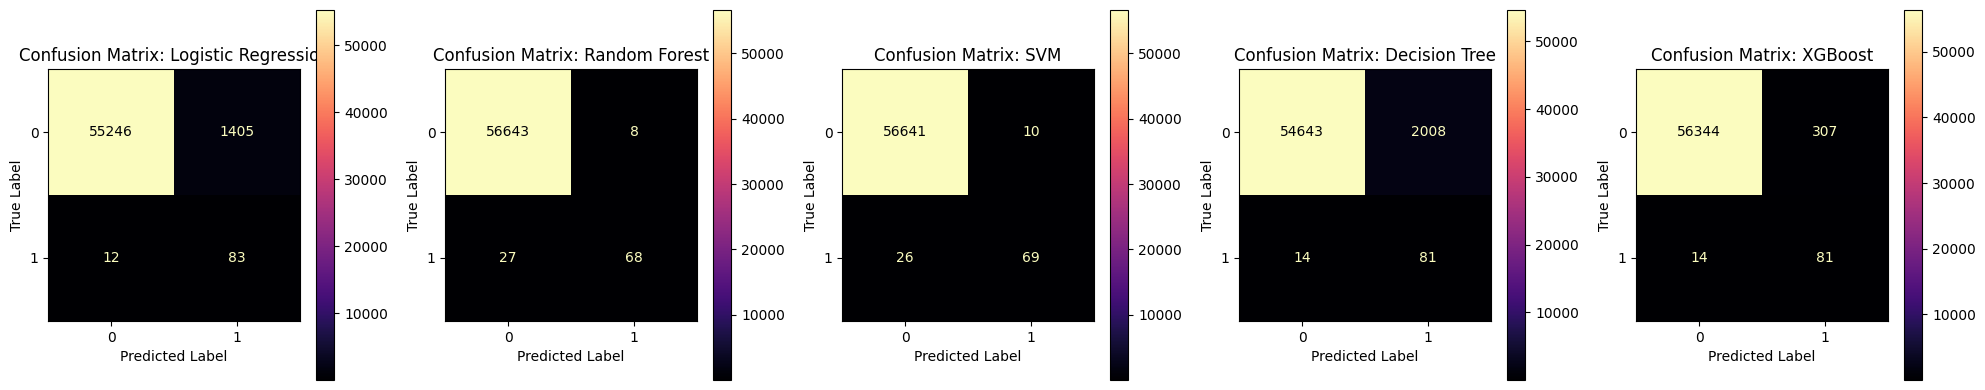

In [ ]:
# Get the number of models to determine subplot layout
num_models = len(best_models)

# Create a figure with subplots dynamically
# Adjust figsize based on the number of models
fig, axes = plt.subplots(1, num_models, figsize=(4 * num_models, 4))

# Ensure axes is iterable even if there's only one model
if num_models == 1:
    axes = [axes]

# Iterate through each model and plot its confusion matrix
for i, (name, model_pipeline) in enumerate(best_models.items()):
    ConfusionMatrixDisplay.from_estimator(model_pipeline, X_test, y_test, cmap='magma', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [ ]:
#Take the entire dataset for evaluation
X= df.copy()
#only choose columns  as of X_train
X = X[X_train.columns]
y = df['Class']
y.head(2)
# y should be actually mapped to 0 and 1  from False and True
y = y.map({False: 0, True: 1})

### Comparison of Models: Training Time vs. Test Recall

Categorial comparisons of training duration and the recall score of each of best model estimatiors. This helps in understanding the trade-offs between model complexity (and thus training time) and its ability to detect positive cases.

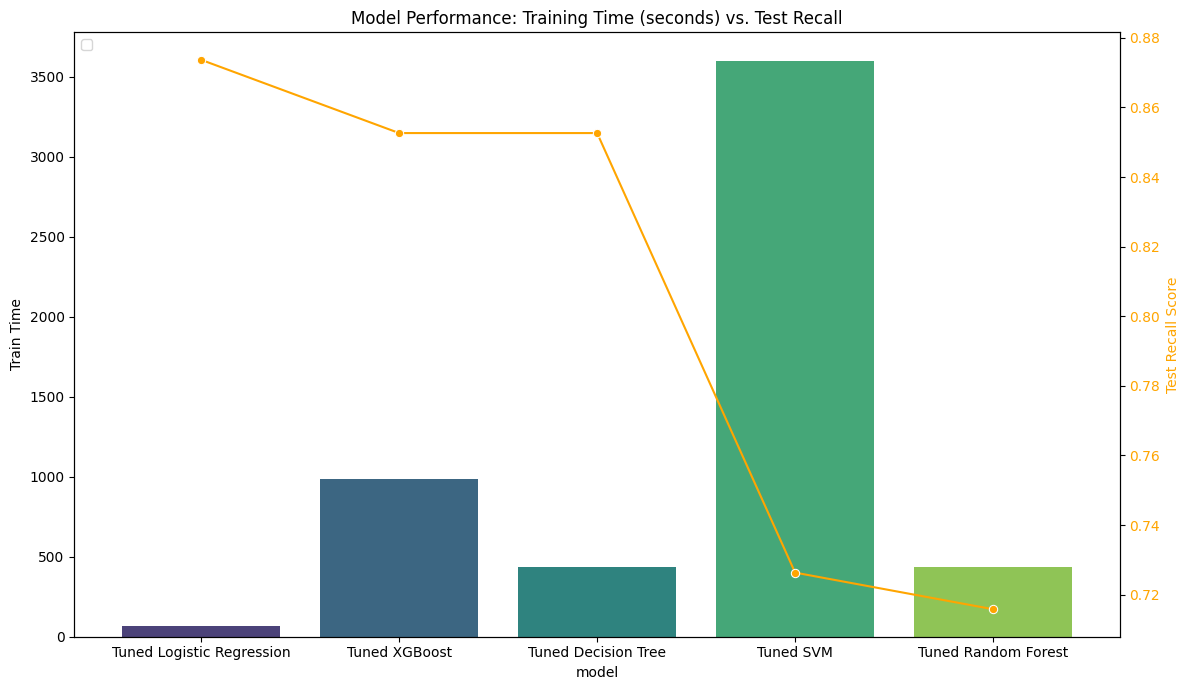

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Training Time on ax1
sns.barplot(data=gs_results_cv_df, x="model", y="Train Time", palette="viridis", ax=ax1, hue="model", legend=False)
ax2.set_xlabel("Model")
ax2.set_ylabel("Training Time (seconds)", color='purple')
ax2.tick_params(axis='y', labelcolor='purple')
ax2.tick_params(axis='x', rotation=45)

# Create a second y-axis for Test Recall
ax2 = ax1.twinx()
sns.lineplot(data=gs_results_cv_df, x="model", y="Test Recall",  color='orange', ax=ax2, sort=False, marker='o')
ax2.set_ylabel("Test Recall Score", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Add a title and legend
plt.title("Model Performance: Training Time (seconds) vs. Test Recall")

# Manually create a legend for both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, ['Training Time'] + ['Test Recall'], loc='upper left')

plt.tight_layout()
plt.show()

Comparison plot for AUPRC and ROC across the fine tuned models .

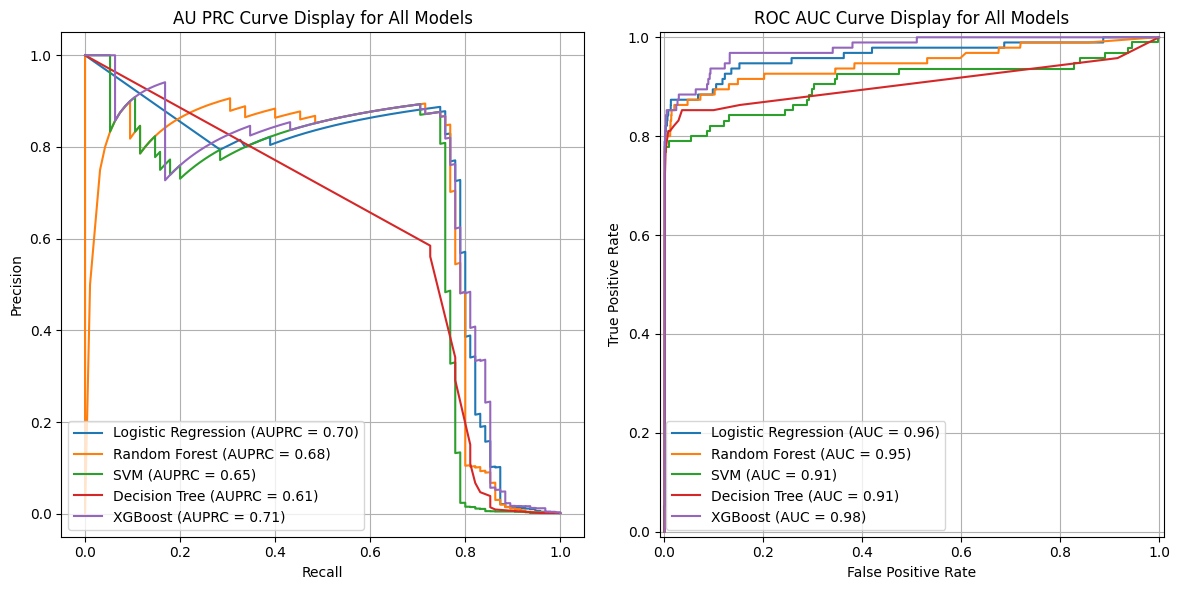

In [ ]:
from sklearn.metrics import precision_recall_curve, auc, RocCurveDisplay
# Plot the PRC Curve and ROC Curve display for all the models with different color lines and legend
plt.figure(figsize=(12, 6))
ax1 = plt.subplot(1, 2, 1)
for name, model in best_models.items():
    # Use X_test and y_test for PRC curve as a whole

          proba = model.predict_proba(X_test)[:, 1]
          precision, recall, _ = precision_recall_curve(y_test, proba)
          pr_auc = auc(recall, precision) # Calculate AUPRC
          ax1.plot(recall, precision, label=f'{name} (AUPRC = {pr_auc:.2f})') # Add AUPRC to label

ax1.set_title("AU PRC Curve Display for All Models")
ax1.set_xlabel("Recall")
ax1.set_ylabel("Precision")
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 2, 2)
for name, model in best_models.items():
    # Use X_test and y_test for ROC curve
          RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax2, name=name)

ax2.set_title("ROC AUC Curve Display for All Models")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

It can be easily seen that Logistic Regression and XGBoost have highest recall score so far compared to others and also a moderate trainign time , compared to slow SVM which also has same recall score and marginally better . Decision tree has horrible recall score probably due to overfitting .

Top models for AUPRC -
XGBoost (ROC - AUC 0.98  v good class discrimination, PRC - 0.71)
Logistic Regression (AUC 0.96 and AUPRC - 0.7)

### **Ensemble Experiment : Weighted Consensus (LR + XGB + SVM)**
We will now combine the  Logistic Regression model with the best XGBoost estimator identified in the Grid Search. We'll use a `VotingClassifier` with soft voting (by probabilities) to see if the ensemble consensus improves the AUPRC.

In this step, we combine three distinct learners:
1. **Logistic Regression (LR):** The high-recall specialist via grid search (min FN gs hence assigning maximum weight here)

2. **XGBoost (XGB):** The high-precision, balanced performer from grid search.

3. **SVM :** Added with a 10% weight to balance for 26 FNs, cant afford these many but SVM FP being low , hopefully it would balance out the above 2 models for FPs without affecting FNs much for the overall combination.

We distribute weights (0.5, 0.4, 0.1) to ensure RF contributes exactly 10% to the final probability average.

Fitting Weighted Ensemble... at 2026-06-01 19:23:40.752794 UTC

Weighted Ensemble Performance (Test Set):
Recall: 0.8632
Precision: 0.1397
AUPRC: 0.6751


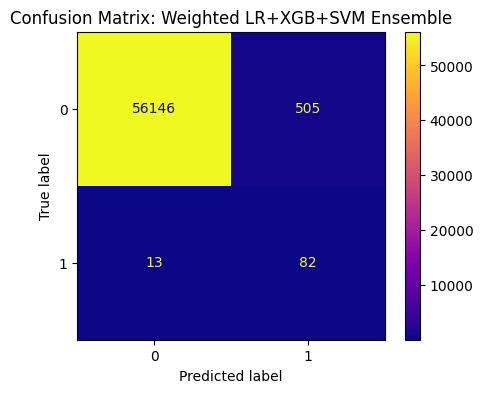

In [ ]:
from sklearn.metrics import average_precision_score
best_lr = best_models['Logistic Regression']
best_xgb = best_models['XGBoost']
best_svm = best_models['SVM'] ## high precision 0.873418 but lesser FN than RF

# Weights: LR=0.5, XGB=0.4, SVM=0.1 (SVM gets 10% weight)
weighted_voting_clf = VotingClassifier(
    estimators=[
        ('best_lr', best_lr),
        ('xgb_tuned', best_xgb),
        ('svm_tuned', best_svm)
    ],
    voting='soft',
    weights=[0.5, 0.4, 0.1]
)

print(f"Fitting Weighted Ensemble... at {datetime.now()} UTC") # train on whole data as basically it is the same as what 2 best models were trained on.
weighted_voting_clf.fit(X_train, y_train)

# take entire test set for predictions
y_te_pred_weighted = weighted_voting_clf.predict(X_test)  # This would be the class predictions from the combination model
y_te_proba_weighted = weighted_voting_clf.predict_proba(X_test)[:, 1]

print("\nWeighted Ensemble Performance (Test Set):")
print(f"Recall: {recall_score(y_test, y_te_pred_weighted):.4f}")
print(f"Precision: {precision_score(y_test, y_te_pred_weighted):.4f}")
print(f"AUPRC: {average_precision_score(y_test, y_te_proba_weighted):.4f}")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_te_pred_weighted, cmap='plasma', ax=ax)
plt.title('Confusion Matrix: Weighted LR+XGB+SVM Ensemble')
plt.show()

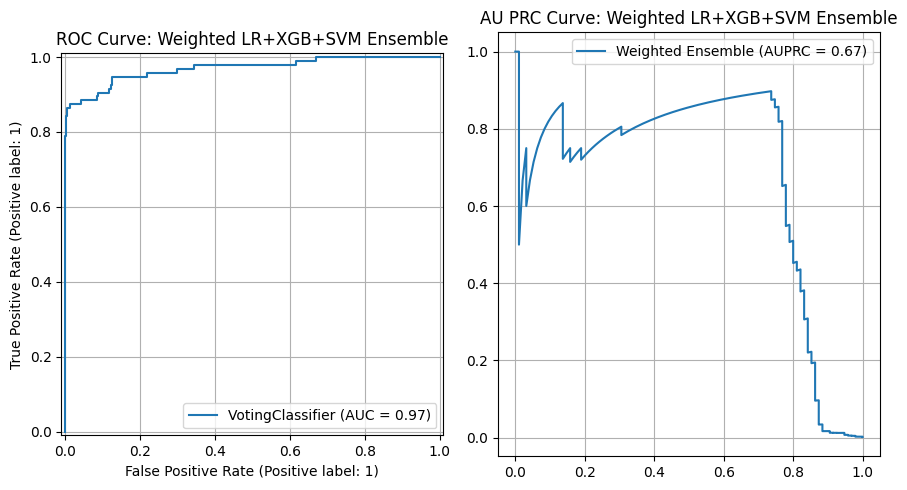

In [ ]:
# Plot the ROC and PRC curves for this voting classifier
# import auc
from sklearn.metrics import auc
fig, ax = plt.subplots(1, 2, figsize=(9, 5))
RocCurveDisplay.from_estimator(weighted_voting_clf, X_test, y_test, ax=ax[0])
ax[0].set_title('ROC Curve: Weighted LR+XGB+SVM Ensemble')
ax[0].grid(True)

precision, recall, _ = precision_recall_curve(y_test, y_te_proba_weighted)
pr_auc = auc(recall, precision)
ax[1].plot(recall, precision, label=f'Weighted Ensemble (AUPRC = {pr_auc:.2f})')
ax[1].set_title('AU PRC Curve: Weighted LR+XGB+SVM Ensemble')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

### **Scatter Plots for Class Discrimination with Weighted Ensemble**

These scatter plots visualize the separation between fraudulent (class 1) and non-fraudulent (class 0) transactions across various feature pairs, providing further insights into the discriminative power of the features leveraged by the Weighted Ensemble model. We'll specifically look at `log_amount`, `hour_sin`, `hour_cos`, and selected PCA components (`V10`, `V12`, `V14`, `V17`)  as was done during EDA after finding these ones to be the most influential .


Only including some pairs which showed clear boundaries

We can visualy identify which pairs of features show some degree of discrimination between classes.

Added 1 more color for False negative to pinpoint regions in this projected 2D subspace where False Negatives tend to cluster, which demonstrate  feature-specific challenges in misclassifications for high dimensional and complex fraud data.



Generating 15 scatter plots based on Weighted Ensemble predictions...


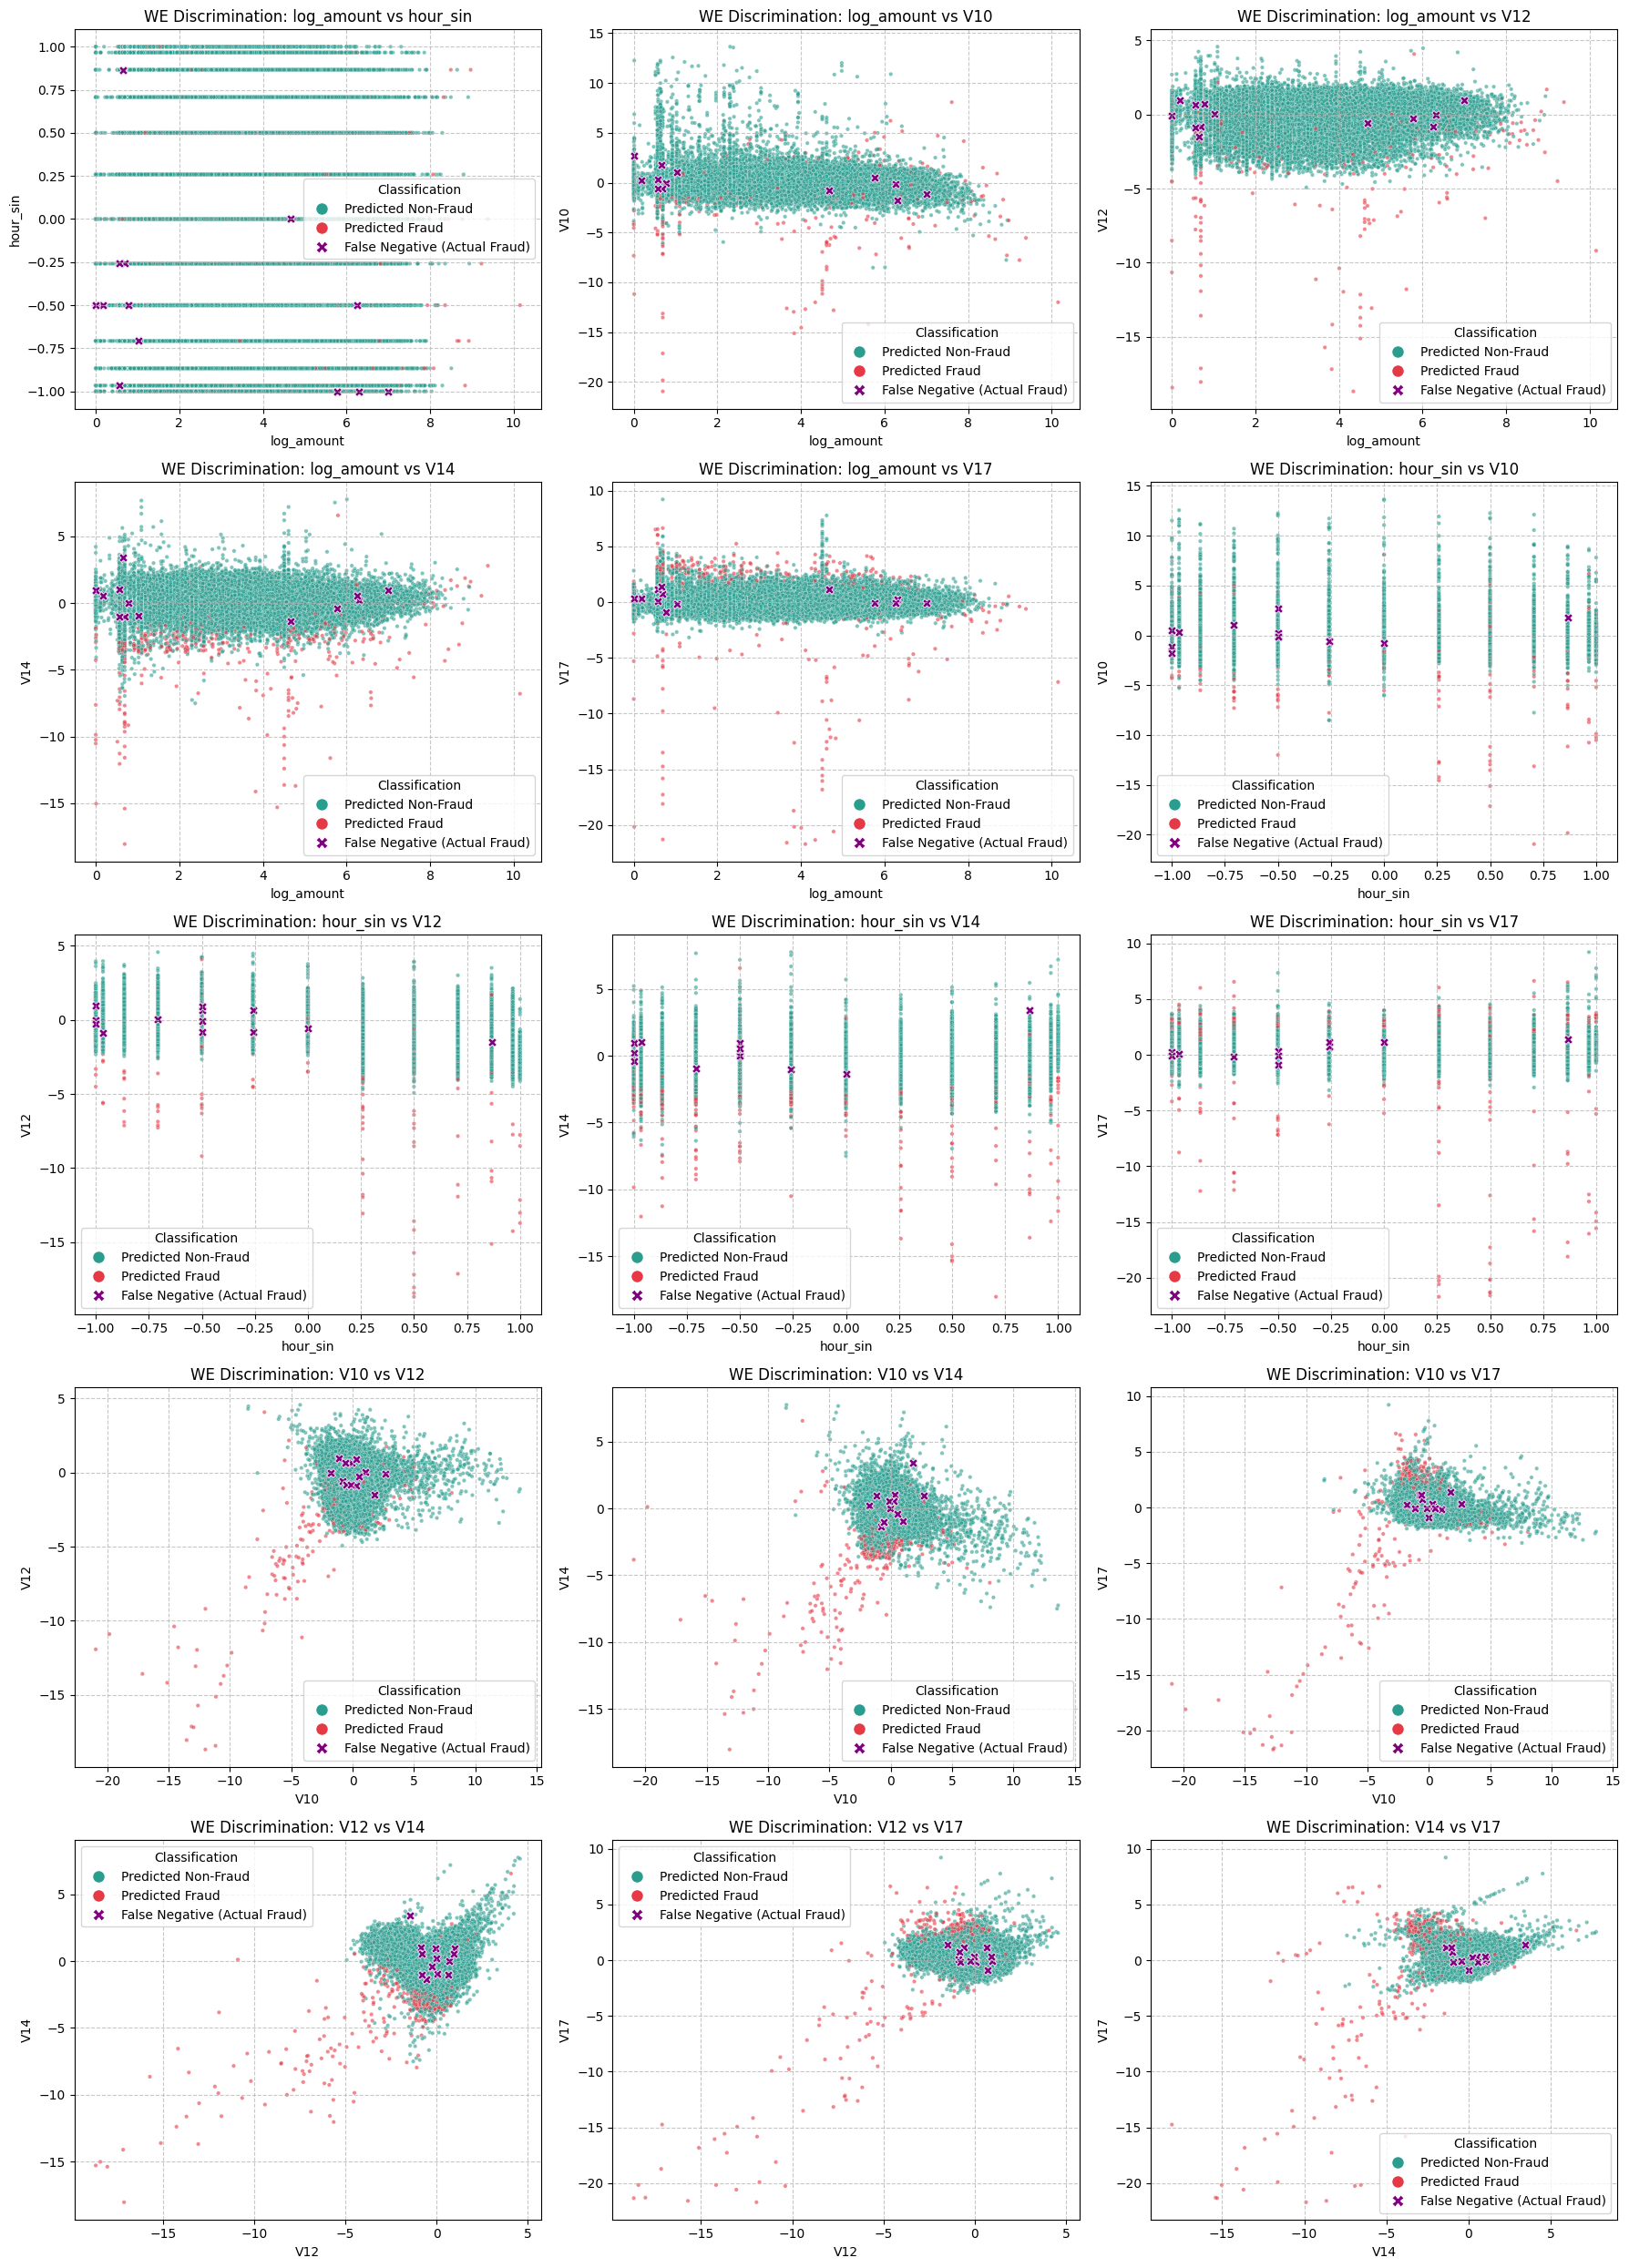

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# After trying a few pairs with manual inspection, only showing class discrimination for pairs with perceivable separation.

# Define the features to plot
features_to_plot = ['log_amount', 'hour_sin', 'V10', 'V12', 'V14', 'V17']

# Create all unique pairs of features
feature_pairs = []
for i in range(len(features_to_plot)):
    for j in range(i + 1, len(features_to_plot)):
        feature_pairs.append((features_to_plot[i], features_to_plot[j]))

# Create a DataFrame for plotting ensemble predictions on the test set
# Ensure X_test contains the required feature columns
ensemble_plot_df = X_test[features_to_plot].copy()
ensemble_plot_df['predicted_class'] = y_te_pred_weighted
ensemble_plot_df['actual_class'] = y_test.values # Add actual_class for comparison

# Identify False Negative instances (Actual fraud but predicted non-fraud)
false_negatives_df = ensemble_plot_df[
    (ensemble_plot_df['actual_class'] == 1) & (ensemble_plot_df['predicted_class'] == 0)
].copy()

print(f"Generating {len(feature_pairs)} scatter plots based on Weighted Ensemble predictions...")

# Calculate the number of rows and columns for subplots
num_plots = len(feature_pairs)
num_cols = 3 # Desired number of columns
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 6, num_rows * 5)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Define palette for predicted classes (keeping original colors for consistency)
predicted_class_palette = {1: '#E63946', 0: '#2A9D8F'} # Red for Predicted Fraud (1), Blue-Green for Predicted Non-Fraud (0)

# Define color for False Negatives
false_negative_color = 'purple' # A distinct color for missed fraud

# Generate and display plots for each pair, colored by ensemble predictions
for i, (feature1, feature2) in enumerate(feature_pairs):
    ax = axes[i]

    # Plot all points by predicted_class first
    sns.scatterplot(x=feature1, y=feature2, hue='predicted_class', data=ensemble_plot_df,
                    alpha=0.6, s=10, hue_order=[1,0], palette=predicted_class_palette, ax=ax, legend=False) # Removed legend to manually create a clearer one

    # Overlay False Negatives with a distinct color and larger 'X' marker
    sns.scatterplot(x=feature1, y=feature2, data=false_negatives_df,
                    color=false_negative_color, s=50, marker='X', ax=ax, legend=False)

    ax.set_title(f'WE Discrimination: {feature1} vs {feature2}')
    ax.set_xlabel(feature1)
    ax.set_ylabel(feature2)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Manually create a combined legend for clarity
    pred_fraud_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=predicted_class_palette[1], markersize=10)
    pred_non_fraud_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=predicted_class_palette[0], markersize=10)
    fn_handle = Line2D([0], [0], marker='X', color='w', markerfacecolor=false_negative_color, markersize=10)

    ax.legend(handles=[pred_non_fraud_handle, pred_fraud_handle, fn_handle],
              labels=['Predicted Non-Fraud', 'Predicted Fraud', 'False Negative (Actual Fraud)'],
              title='Classification')


# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### **Ensemble Threshold Optimization (Done separately)**
When we perform a grid search over decision thresholds to maximize **Recall** and evaluate the resulting trade-offs, we find that the number of FPs increase exponentially , indicating that the above voting ensemble is the best in terms of highest recall balancing AUPRC compared to Logistic Regression (Tuned with class weights) which had highest recall.

Though considering a recall-first approach would tilt the choice in fvor of LogisticRegression, XGBoost does exceedingly well in avoiding a lot of False Positives seen in LR .

A combination model of these 2 estimators provides a fine balance between Precision and Recall, significantly improving upon the False Positive cases using SVM as the 3rd participant.

Further tuning on this particular dataset using voting classifier did not improve the model.

Optimal Threshold (Max F1): 0.50
Best F1 Score: 0.0000

Performance at Optimal Threshold:
Recall: 0.8632
Precision: 0.1397


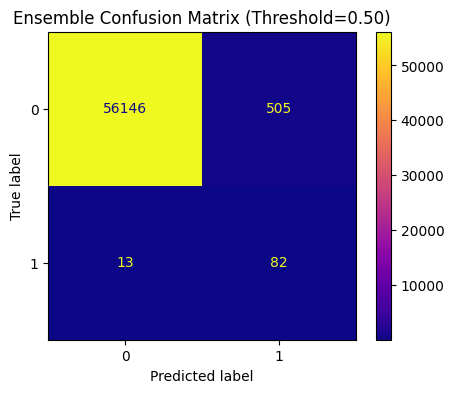

In [ ]:
# Plot the confusion matrix for the ensemble

import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

# Define the range of thresholds to test
thresholds = np.arange(0.01, 0.005, 0.008)

results = []
best_f1 = 0
optimal_threshold = 0.5

# Iterate through thresholds to find the one that maximizes F1 score
for t in thresholds:
    y_pred_t = (y_te_proba_weighted >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)

    results.append({'threshold': t,'f1': f1,'recall': rec,'precision': prec})

    if f1 > best_f1:
        best_f1 = f1
        optimal_threshold = t

print(f"Optimal Threshold (Max F1): {optimal_threshold:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")

# Evaluate at the optimal threshold
y_final_pred = (y_te_proba_weighted >= optimal_threshold).astype(int)

print("\nPerformance at Optimal Threshold:")
print(f"Recall: {recall_score(y_test, y_final_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_final_pred):.4f}")

# Display Confusion Matrix for the optimized threshold
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_final_pred, cmap='plasma', ax=ax)
plt.title(f'Ensemble Confusion Matrix (Threshold={optimal_threshold:.2f})')
plt.show()

### **Effectiveness measurement using Lift Curve**

A ift curve is often used by a bank to prioritize the customers they would do targetted campaigning for. In fraud detection also, credit card issuing agencies may follow the exact same approach.

A  lift curve will plot a model's ability to rank the probabilities of the data points to be classified as positive class (this case fraud) with respect to random guesssing.
It essentially answers the question for model -

*" If I investigate highest risk cases first , how much better I am doing than random guessing"*

Imagine in this dataset , we have 280K records, fraud cases = 0.18% eq 500 cases of fraud .

Top 10 decile(28000 data point) - after ranking by probability, random guessing would be 50 fraud cases .

 Suppose , I identify from highest probabilities in these 28000 cases - 200 fraud cases , we say Lift@10% = 4(200/50).  A model with higher lift is considered better .

In [ ]:
def calculate_lift_at_deciles(y_true, y_probas, deciles=[0.1, 0.2, 0.3, 0.4, 0.5]):
    # Sort data in descending order of their probabilities predicted by the model
    df_lift = pd.DataFrame({'actual': y_true, 'prob': y_probas})
    df_lift = df_lift.sort_values(by='prob', ascending=False).reset_index(drop=True)

    # Total count of all fraud cases
    total_positives = df_lift['actual'].sum()
    total_count = len(df_lift)
    baseline_rate = total_positives / total_count
    #we see that baseline rate is same as our original fraud dist = 0.17 in the output
    #Print all the above values  in one line
    print(f"Total Positives: {total_positives}, Total Count: {total_count}, Baseline Rate: {baseline_rate:.4f}")

    lift_results = {}
    for d in deciles:
        num_samples = int(d * total_count)
        frauds_at_d = df_lift['actual'].iloc[:num_samples].sum()
        rate_at_d = frauds_at_d / num_samples
        lift = rate_at_d / baseline_rate
        lift_results[f'Decile {int(d*100)}%'] = round(lift, 2)

    return lift_results

# Calculate lift for the weighted ensemble probabilities
lift_values = calculate_lift_at_deciles(y_test, y_te_proba_weighted)

print("Lift Values for only the Weighted Ensemble Model:")
for decile, value in lift_values.items():
    print(f"{decile}: {value}x")

y_te_proba_weighted = weighted_voting_clf.predict_proba(X_test)[:, 1]


Total Positives: 95, Total Count: 56746, Baseline Rate: 0.0017
Lift Values for only the Weighted Ensemble Model:
Decile 10%: 9.05x
Decile 20%: 4.74x
Decile 30%: 3.19x
Decile 40%: 2.45x
Decile 50%: 1.96x


Install scikit plot for plotting the lift cureve

In [ ]:
!pip install scikit-plot

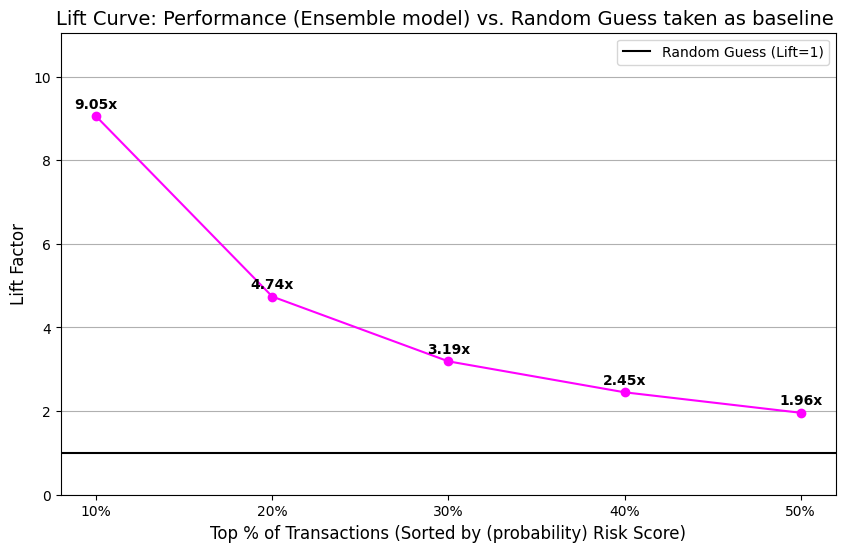

In [ ]:
import scipy
scipy.interp = np.interp

import scikitplot as skplt # Although not used for custom plotting, kept for context

# 1. Prepare data for plotting
lift_data = pd.DataFrame({
    'Decile': [10, 20, 30, 40, 50],
    'Lift': [lift_values['Decile 10%'], lift_values['Decile 20%'],
             lift_values['Decile 30%'], lift_values['Decile 40%'],
             lift_values['Decile 50%']]
})

# 2. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(lift_data['Decile'].astype(str) + '%', lift_data['Lift'], marker='o', color ='magenta')

# Add baseline which is simply random guessing .
plt.axhline(y=1, color='black', linestyle='-', label='Random Guess (Lift=1)')

# Annotate lift points with values
for i, val in enumerate(lift_data['Lift']):
    plt.text(i, val + 0.2, f'{val}x', ha='center', fontweight='bold')

plt.title('Lift Curve: Performance (Ensemble model) vs. Random Guess taken as baseline ', fontsize=14)
plt.xlabel('Top % of Transactions (Sorted by (probability) Risk Score)', fontsize=12)
plt.ylabel('Lift Factor', fontsize=12)
plt.ylim(0, max(lift_data['Lift']) + 2)
plt.legend()
plt.grid(axis='y')
plt.show()

### **Lift Values for Individual Models and Weighted Ensemble**

Now, we will calculate and display the lift values for the top 3 deciles (1%, 5%, 10%) for each of the best-performing individual models (Logistic Regression, Random Forest, SVM, Decision Tree, XGBoost) and the Weighted Ensemble. This will allow for a direct comparison of their ability to identify positive cases at the highest risk segments.

In [ ]:
# Define deciles for detailed analysis for the table and plotting
deciles_to_plot = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
deciles_to_display = [1, 5, 10]

# Dictionary to store lift data for all models
all_models_lift_data = []

# Calculate lift for individual models
for model_name, model_pipeline in best_models.items():
    print(f"Calculating probabilities and lift for {model_name}...")
    # Get positive class probabilities
    y_probas_model = model_pipeline.predict_proba(X_test)[:, 1]

    # Calculate lift values using the existing function
    model_lift_values_dict = calculate_lift_at_deciles(y_test, y_probas_model, deciles=[d / 100 for d in deciles_to_display])

    # Store in a list of dictionaries for easy DataFrame conversion
    for decile_percent, lift_val in model_lift_values_dict.items():
        all_models_lift_data.append({
            'Model': model_name,
            'Decile': decile_percent.replace('Decile ', '').replace('%', ''), # Clean string to just number
            'Lift': lift_val
        })

# Calculate lift for the Weighted Ensemble
print("Calculating probabilities and lift for Weighted Ensemble...")
weighted_ensemble_lift_values_dict = calculate_lift_at_deciles(y_test, y_te_proba_weighted, deciles=[d / 100 for d in deciles_to_display])

for decile_percent, lift_val in weighted_ensemble_lift_values_dict.items():
    all_models_lift_data.append({
        'Model': 'Weighted Ensemble',
        'Decile': decile_percent.replace('Decile ', '').replace('%', ''),
        'Lift': lift_val
    })

# Create a DataFrame from the collected data
comparison_lift_df = pd.DataFrame(all_models_lift_data)
comparison_lift_df['Decile'] = comparison_lift_df['Decile'].astype(int)

# Pivot the table for better readability
pivoted_lift_df = comparison_lift_df.pivot(index='Model', columns='Decile', values='Lift')
pivoted_lift_df.columns.name = 'Decile (%)'

display(pivoted_lift_df.sort_values(by=[1,5], ascending=False))


Calculating probabilities and lift for Logistic Regression...
Total Positives: 95, Total Count: 56746, Baseline Rate: 0.0017
Calculating probabilities and lift for Random Forest...
Total Positives: 95, Total Count: 56746, Baseline Rate: 0.0017
Calculating probabilities and lift for SVM...
Total Positives: 95, Total Count: 56746, Baseline Rate: 0.0017
Calculating probabilities and lift for Decision Tree...
Total Positives: 95, Total Count: 56746, Baseline Rate: 0.0017
Calculating probabilities and lift for XGBoost...
Total Positives: 95, Total Count: 56746, Baseline Rate: 0.0017
Calculating probabilities and lift for Weighted Ensemble...
Total Positives: 95, Total Count: 56746, Baseline Rate: 0.0017


Decile (%),1,5,10
Model,,,
Weighted Ensemble,86.39,17.69,9.05
XGBoost,85.33,17.69,9.37
Logistic Regression,85.33,17.48,8.95
Decision Tree,81.12,17.05,8.53
Random Forest,80.06,17.48,8.84
SVM,79.01,15.79,8.21


**Conclusion**

The lift at 10% is 9.05x . This lift curve serves as a final confirmation that in spite of low precision (0.1431), by focusing on top 10% of the transactions identified as risky (not calling it fraud here because they are based  off probability , hence some could be non-fraud as well), our ensemble model is effectively better 9.05 times than a random sampler.

This value though same for XGBoost but if we narrow down to top 1% of the entiree test set, WE is 86.39 vs XGB and LR both tied at 85.33 edging past the second best.

Hence , Weighted ensemble emerges as the winner for this fraud classification as far as supervised learning is concerned.

### **8. Saving Key Components for Future Use**

To facilitate continuation of work in other notebooks or sessions, we will save the preprocessed data, the train-test split, the best-performing models, and the evaluation results using the `pickle` module.

We have used this data furher for training unsupervised models in another notebook.

Please follow the Unuspervised_learning notebook in the given github repo to continue there.

In [ ]:
import pickle
import os

# Define a directory to save the files
save_dir = '/content/saved_model_components'
os.makedirs(save_dir, exist_ok=True)

# Save the preprocessor
with open(os.path.join(save_dir, 'preprocessor.pkl'), 'wb') as f:
    pickle.dump(preprocessor, f)
print(f"Preprocessor saved to {os.path.join(save_dir, 'preprocessor.pkl')}")

# Save the train/test splits
with open(os.path.join(save_dir, 'X_train.pkl'), 'wb') as f:
    pickle.dump(X_train, f)
with open(os.path.join(save_dir, 'X_test.pkl'), 'wb') as f:
    pickle.dump(X_test, f)
with open(os.path.join(save_dir, 'y_train.pkl'), 'wb') as f:
    pickle.dump(y_train, f)
with open(os.path.join(save_dir, 'y_test.pkl'), 'wb') as f:
    pickle.dump(y_test, f)
print("Train/test data saved.")

# Save the dictionary of best models
with open(os.path.join(save_dir, 'best_models.pkl'), 'wb') as f:
    pickle.dump(best_models, f)
print(f"Best models saved to {os.path.join(save_dir, 'best_models.pkl')}")

# Save the results DataFrame
with open(os.path.join(save_dir, 'df_results_cvf.pkl'), 'wb') as f:
    pickle.dump(df_results_cv, f)
print(f"Results DataFrame saved to {os.path.join(save_dir, 'df_results_cv.pkl')}")

Preprocessor saved to /content/saved_model_components/preprocessor.pkl
Train/test data saved.
Best models saved to /content/saved_model_components/best_models.pkl
Results DataFrame saved to /content/saved_model_components/df_results_cv.pkl


In [ ]:
# Save the predictions and their probabilities as well
with open(os.path.join(save_dir, 'y_te_pred_weighted.pkl'), 'wb') as f:
    pickle.dump(y_te_pred_weighted, f)
with open(os.path.join(save_dir, 'y_te_proba_weighted.pkl'), 'wb') as f:
    pickle.dump(y_te_proba_weighted, f)

# Save the voting classifier model as well
with open(os.path.join(save_dir, 'weighted_voting_clf.pkl'), 'wb') as f:
    pickle.dump(weighted_voting_clf, f)

---
**Borderline SMOTE**
These findings also  indicate that Borderline SMOTE does not
improve the results significantly for fraud detection in this
dataset. Despite the scarcity of fraud instances, the gener
ated synthetic data introduces noise and adversely affects
most models’ performance. Decision Trees and Random
Forest, leveraging the inherent nature of fraud occurrences
as closely related and rare events, outperform other models
in this scenario.

--

**SVM and Decision Trees**

While some models like SVM and Decision Trees produced minimal False positives, they are either too memory intensive and time consuming , or grossly overfit to unseeen data.

**Ensemble and other supervised models**

*   Careful selection of constituent estimators is necessary to strike a balance between precision and recall in imbalanced datasets . Choice of SVM was necessary to reduce the False positives in the ensemble with carefully tuned weights .

*   Neural Network (MLP) is an excellent choice to achieve a decent AU PRC score and a good F1-score to strike this balance as well. With more experminets around latent space, it could be further improved.

*   For comparable scores between models, time taken to train needs consideration as well.

**Artificail Neural Network (MLP)**
Model	Accuracy	Precision	Recall	F1-Score
0	Keras MLP with SMOTE	0.996775	0.321138	0.831579	0.463343

Conclusions on ANN ANN is able to find many hidden relationships within the normal and fraud data which shows up in the high recall and accuracy . Moreover it is able to draw a clear distinction between the positive and negative classes.

We see that the number of False negatives is quite admissable at 16 FN- 16 and TP-79 for comparing against the Keras implementation of MLP ANN against other models in the main notebook namely XGB and VC.

A very high recall score of 0.831579 and AUC ROC - 0.94 is quite a robust model for fraud detection.


### **Limitations of this approach and Further improvements**
1. Having PCA transformed input data naturally reduced interpretability though interesting patterns could be drawn via pairwise scatter plots .

2. The comparions of certain supervised algorithms such as SVM and Random Forest had to be done on a much reduced dataset compared to others due to computational limitations.

*A large organization would however invest in superior hardware and higher specifications (RAM/GPUs) to avoid long running traning process timing out.*

**Time Factor**
We can see that most of the transactions happend during day time and least numbers of transactions hapended during nigh This provided great temporal imputs on developing time sensitive models from recent past behaviour.

Given this dataset does not have customer centric information for time component ,sequence models such as Neural networks (LSTM) cannot be used to find ordered patterns .

The transactions can be further broken down in days_of_week, time_of_day, weekend etc in developing more robust models.

**Location as a feature** GPS location of device through which transaction is being carried out need to be captured as a feaure.

**Detailed technical and business insights* attached to the final report.


**Business insights and recommendations**

###  Implement the following workflow for verifying and blocking transactions as per the below
                  ┌─────────────────────────────┐
                  │ Predicted Probabilities (Y) │
                  └──────────────┬──────────────┘
                                 │
                     [ Is Y ≥ Threshold? ]
                                 │
                   ┌─────────────┴─────────────┐
                  Yes                         No
                   │                           │
          ┌────────┴────────┐         ┌────────┴────────┐
          │  Class 1: Fraud │         │ Class 0: Normal │
          └────────┬────────┘         └────────┬────────┘
                   │                           │
          ┌────────┴────────┐         ┌────────┴────────┐
          │ Text Alert Sent │         │ Process Payment │

Instead of using a static threshold , a lift curve works exceptionally well for businesses where random guessing could be dangerous . It would help the business maximize fraud capture rates with interpretable visualizations to keep operational constraints within budget .

**Resource constrains** - Limited resource optimzation by ranking the riskiness using the scores above , 9.05x was the lift at 10% whereas 86.39 times at 1% of test population which is great , it essentially means reviewing just 10% of top risky flagged cases , we can focus on 9 times random guessing . This is crucial for stakeholder communication .

* Customer outreach - Call and confirm the legitimacy of transactions when
flagged.Block card transaction - Call and verify

* "time" of transaction can be significant indicator, hence build support resourcing to be extra vigilant in order for customer outreach .

* Feature Importance- Map the PCA features back to the original set of interpretable features to decide course of action.

* Some preventive steps by business could be two step authentication to discourage account takeover , FaceID + Biometrics recongnition

* Need for further model deployments  by scalability and suitability to actual business, millions of transactions happen across various online platofrms such as Mobile device , internet , payment gateways , POS sale purchase , Direct Debits, Scheduled transfers to name a few . Hence , fraud assessment algorithms need to evolve and move byond a binary classification to multinomial classification models in order to optimize resource spend in improving transaction processes.

* More sophisticated algorithms in order to detect new evolving complex fraud patterns.

* Many of these are organzied crimes and are carried out from a specific location , in addition, these device ips could be masked as well hence institutions should invest in cybersecurity and ethical hacking as well in order to unmask fraudsters .

-------------------------------------------------------------------------------

**Top Decile Performance**: Both models provide a massive performance boost over random guessing. The Tuned XGBoost shows a slightly higher lift in the top 10% of transactions compared to the Logistic Regression component.

**Risk Segmentation**: The visualization confirms that by investigating only the top 10% of the riskiest transactions (as ranked by the models), you would capture significantly more fraudulent cases than a random audit.

**Best model** : Ultimaltely, choice of 'best model' is by business design instead of raw metrics which should taken only as guide. Primarily , it is guided by customer base and the risk tolerance that the issuing firms find acceptable. Each company would have different transactional patterns.

For an unsupervised model lerning pattern only from the inout data , Isolation Forest model provides a good alternative to supervised models for credit card merchants who do not have enough representation in the market or enough consumer base to develop a transaction pattern for eg- New card companies issuers or existing company venturing into credit business.

Additionally , for emerging and completely unseen fraud patterns (called zero day in financial terminology), unsupervised learning techniques such as OneClassSVM (novelty detection) is also a good alternative because it is also immune to class imbalance and discovers anomalies after understanding normal tranactional pattern only .